# GP Occupancy Full EFE Experiment

This notebook is the experiment-focused companion to the GP occupancy
sandbox. It is meant to feel closer to
`diffdrivenav-bev2image-efe .ipynb`: a real EFE study where you can follow
the planned path, the executed path, and the ambiguity/risk differences
over time.

The setting is intentionally simplified:
- one occluder,
- visible start,
- goal across a shadowed region,
- three planner views: constant `R`, true-map `q(x)`, and GP-occupancy `q(x)`.

Instead of continuous trajectory optimization, this notebook uses a small
sequence library of unicycle control templates. That keeps the EFE logic
explicit while still producing interpretable planned paths at each replan
step.


In [4]:
import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "scripts").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize
from scipy.stats import multivariate_normal
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from scripts.botnav_efe_helpers import (
    UnicycleEFEAgent,
    ET1,
    ET2,
    ambiguity,
    risk,
    predict_unicycle,
    planned_trajectory_unicycle,
    unicycle_step,
)

from scripts.botnav_efe_jax import (
    bind_unicycle_agent_jax,
    make_homography_g_jax,
    unicycle_step_jax,
    unicycle_jacobian_jax,
)

from scripts.state_dependent_observation_helpers import (
    covariance_logdet_series,
    covariance_trace_series,
    effective_covariance,
    evaluate_visibility_on_grid,
    make_default_camera,
    make_observation_fn,
    make_occupancy_grid,
    observation_covariance,
    process_covariance_from_rho,
    raycast_visibility_q,
)

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2

rng = np.random.default_rng(12)


In [ ]:
camera = make_default_camera()
camera_xy = np.asarray(camera.cam_pos[:2], dtype=float)

obstacle_rect = (0.35, 0.85, -1.75, -0.55)

true_grid = make_occupancy_grid(
    xmin=-4.5,
    xmax=2.8,
    ymin=-4.8,
    ymax=1.0,
    resolution=0.1,
    rectangles=[obstacle_rect],
    circles=None,
    border_occupancy=True,
)

start_state = np.array([-0.35, 0.8, -np.pi / 2], dtype=float)
goal_state = np.array([1.20, -4.35, 0.0], dtype=float)

blocked_state = np.array([0.60, -2.10, 0.0], dtype=float)
shadow_state = np.array([1.35, -2.15, 0.0], dtype=float)


def sample_occ(grid, x, y):
    xs_local = grid.xs
    ys_local = grid.ys
    occ = grid.occupancy

    if x <= xs_local[0] or x >= xs_local[-1] or y <= ys_local[0] or y >= ys_local[-1]:
        return 1.0

    ix = int(np.searchsorted(xs_local, x, side="right") - 1)
    iy = int(np.searchsorted(ys_local, y, side="right") - 1)
    ix = max(0, min(ix, xs_local.shape[0] - 2))
    iy = max(0, min(iy, ys_local.shape[0] - 2))

    x0, x1 = xs_local[ix], xs_local[ix + 1]
    y0, y1 = ys_local[iy], ys_local[iy + 1]
    tx = 0.0 if x1 == x0 else (x - x0) / (x1 - x0)
    ty = 0.0 if y1 == y0 else (y - y0) / (y1 - y0)

    z00 = occ[iy, ix]
    z10 = occ[iy, ix + 1]
    z01 = occ[iy + 1, ix]
    z11 = occ[iy + 1, ix + 1]

    return float(
        (1.0 - ty) * ((1.0 - tx) * z00 + tx * z10)
        + ty * ((1.0 - tx) * z01 + tx * z11)
    )


def first_hit_point(grid, start, end, threshold=0.55, n=180):
    ts = np.linspace(0.0, 1.0, int(max(n, 2)))
    points = np.outer(1.0 - ts, start) + np.outer(ts, end)
    occ_values = np.asarray([sample_occ(grid, p[0], p[1]) for p in points], dtype=float)
    hit_idx = np.flatnonzero(occ_values >= float(threshold))
    if hit_idx.size == 0:
        return None, points
    idx = int(hit_idx[0])
    return points[idx].copy(), points[: idx + 1].copy()


xs = np.linspace(true_grid.xs.min(), true_grid.xs.max(), 80)
ys = np.linspace(true_grid.ys.min(), true_grid.ys.max(), 64)
Xg, Yg = np.meshgrid(xs, ys)


class SimpleRBFGP:
    def __init__(
        self,
        length_scale=0.20,
        signal_var=1.0,
        noise_var=0.01,
        prior_mean=0.02,
        jitter=1e-8,
    ):
        self.length_scale = float(length_scale)
        self.signal_var = float(signal_var)
        self.noise_var = float(noise_var)
        self.prior_mean = float(prior_mean)
        self.jitter = float(jitter)
        self.X_train = None
        self.y_mean = None
        self.L = None
        self.alpha = None

    def _kernel(self, Xa, Xb):
        Xa = np.asarray(Xa, dtype=float)
        Xb = np.asarray(Xb, dtype=float)
        d2 = np.sum((Xa[:, None, :] - Xb[None, :, :]) ** 2, axis=2)
        ls2 = max(self.length_scale ** 2, 1e-12)
        return self.signal_var * np.exp(-0.5 * d2 / ls2)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)

        self.X_train = X
        self.y_mean = self.prior_mean
        y0 = y - self.y_mean

        K = self._kernel(X, X) + (self.noise_var + self.jitter) * np.eye(X.shape[0])
        self.L = np.linalg.cholesky(K)
        self.alpha = np.linalg.solve(self.L.T, np.linalg.solve(self.L, y0))
        return self

    def predict(self, X, return_std=False):
        X = np.asarray(X, dtype=float)
        Ks = self._kernel(X, self.X_train)
        mu = self.y_mean + Ks @ self.alpha
        if not return_std:
            return mu
        v = np.linalg.solve(self.L, Ks.T)
        var = np.maximum(self.signal_var - np.sum(v * v, axis=0), 1e-12)
        return mu, np.sqrt(var)


def obstacle_pixel_bbox(camera, obstacle_rect):
    ox0, ox1, oy0, oy1 = obstacle_rect
    corners = np.array([
        [ox0, oy0],
        [ox0, oy1],
        [ox1, oy0],
        [ox1, oy1],
    ], dtype=float)
    uv = np.asarray([camera.world_to_pixel(x, y) for x, y in corners], dtype=float)
    return (
        float(np.min(uv[:, 0])),
        float(np.max(uv[:, 0])),
        float(np.min(uv[:, 1])),
        float(np.max(uv[:, 1])),
    )


def pixel_to_world_in_grid(camera, grid, u, v):
    x, y = camera.pixel_to_world(float(u), float(v))
    if not np.isfinite(x) or not np.isfinite(y):
        return None
    if x <= grid.xs[0] or x >= grid.xs[-1] or y <= grid.ys[0] or y >= grid.ys[-1]:
        return None
    return np.array([x, y], dtype=float)


def sample_free_points_along_ray(points, hit_exists):
    points = np.asarray(points, dtype=float)
    if points.shape[0] == 0:
        return np.empty((0, 2), dtype=float)

    if hit_exists:
        qs = np.array([0.15, 0.40, 0.70, 0.92], dtype=float)
    else:
        qs = np.array([0.20, 0.55, 0.90], dtype=float)

    idx = np.unique(np.clip((qs * (points.shape[0] - 1)).astype(int), 0, points.shape[0] - 1))
    return points[idx]


def build_gp_dataset(
    grid,
    camera,
    obstacle_rect,
    start_state,
    goal_state,
    rng,
    *,
    n_rays=520,
    max_free=360,
    max_occ=180,
):
    free_points = []
    occ_points = []

    u_start, v_start = camera.world_to_pixel(float(start_state[0]), float(start_state[1]))
    u_goal, v_goal = camera.world_to_pixel(float(goal_state[0]), float(goal_state[1]))
    umin, umax, vmin, vmax = obstacle_pixel_bbox(camera, obstacle_rect)

    for ray_idx in range(int(n_rays)):
        mode = ray_idx % 5
        end = None

        for _ in range(40):
            if mode == 0:
                u = rng.uniform(60.0, camera.img_width - 60.0)
                v = rng.uniform(60.0, camera.img_height - 60.0)
            elif mode == 1:
                u = rng.uniform(umin - 25.0, umax + 25.0)
                v = rng.uniform(vmin - 20.0, vmax + 20.0)
            elif mode == 2:
                u = rng.uniform(umin - 40.0, umax + 90.0)
                v = rng.uniform(vmin - 40.0, vmax + 40.0)
            elif mode == 3:
                a = rng.uniform(0.0, 1.0)
                u = (1.0 - a) * u_start + a * u_goal + rng.normal(scale=60.0)
                v = (1.0 - a) * v_start + a * v_goal + rng.normal(scale=45.0)
            else:
                if rng.random() < 0.5:
                    u = rng.uniform(umin - 30.0, umax + 30.0)
                    v = rng.uniform(vmin - 55.0, vmin - 10.0)
                else:
                    u = rng.uniform(umin - 30.0, umax + 30.0)
                    v = rng.uniform(vmax + 10.0, vmax + 55.0)

            end = pixel_to_world_in_grid(camera, grid, u, v)
            if end is not None:
                break

        if end is None:
            continue

        hit_point, traversed_points = first_hit_point(
            grid,
            np.asarray(camera.cam_pos[:2], dtype=float),
            end,
            threshold=0.55,
            n=180,
        )

        if hit_point is not None:
            occ_points.append(hit_point.copy())
            free_segment = traversed_points[:-1]
        else:
            free_segment = traversed_points

        sampled_free = sample_free_points_along_ray(free_segment, hit_point is not None)
        for p in sampled_free:
            free_points.append(p.copy())

    free_points = np.asarray(free_points, dtype=float) if free_points else np.empty((0, 2), dtype=float)
    occ_points = np.asarray(occ_points, dtype=float) if occ_points else np.empty((0, 2), dtype=float)

    if free_points.shape[0]:
        free_points = np.unique(np.round(free_points, 3), axis=0)
    if occ_points.shape[0]:
        occ_points = np.unique(np.round(occ_points, 3), axis=0)

    if free_points.shape[0] > int(max_free):
        idx = rng.choice(free_points.shape[0], size=int(max_free), replace=False)
        free_points = free_points[idx]

    if occ_points.shape[0] > int(max_occ):
        idx = rng.choice(occ_points.shape[0], size=int(max_occ), replace=False)
        occ_points = occ_points[idx]

    X_train = np.vstack([free_points, occ_points])
    y_train = np.concatenate([
        np.zeros(free_points.shape[0], dtype=float),
        np.ones(occ_points.shape[0], dtype=float),
    ])
    return X_train, y_train, free_points, occ_points


X_train, y_train, free_points, occ_points = build_gp_dataset(
    true_grid,
    camera,
    obstacle_rect,
    start_state,
    goal_state,
    rng,
)

gp_occ = SimpleRBFGP(
    length_scale=0.18,
    signal_var=1.0,
    noise_var=0.01,
    prior_mean=0.02,
).fit(X_train, y_train)

occ_mu, occ_std = gp_occ.predict(
    np.column_stack([Xg.ravel(), Yg.ravel()]),
    return_std=True,
)

P_occ_gp = np.clip(occ_mu.reshape(Xg.shape), 1e-4, 1.0 - 1e-4)
P_occ_std = occ_std.reshape(Xg.shape)

gp_occ_interp = RegularGridInterpolator(
    (ys, xs),
    P_occ_gp,
    bounds_error=False,
    fill_value=0.02,
)


def p_vis_true_occ(state, tau=8.0, n_samples=120):
    return raycast_visibility_q(
        state,
        true_grid,
        camera_xy,
        tau=tau,
        n_samples=n_samples,
    )


def p_vis_gp_occ(state, tau=8.0, n_samples=120):
    start = camera_xy
    end = np.asarray(state[:2], dtype=float)
    ts = np.linspace(0.0, 1.0, int(max(n_samples, 2)))
    points = np.outer(1.0 - ts, start) + np.outer(ts, end)
    occ_vals = np.clip(
        gp_occ_interp(np.column_stack([points[:, 1], points[:, 0]])),
        1e-4,
        1.0,
    )
    return float(np.clip(np.exp(-float(tau) * float(np.mean(occ_vals))), 0.0, 1.0))


def q_info_geom(state, boundary_margin_px=180.0, range_scale=10.0, q_min=0.6):
    u, v = camera.world_to_pixel(float(state[0]), float(state[1]))
    if not np.isfinite(u) or not np.isfinite(v):
        return float(q_min)

    if u < 0 or u >= camera.img_width or v < 0 or v >= camera.img_height:
        return float(q_min)

    d_boundary = min(u, v, camera.img_width - 1.0 - u, camera.img_height - 1.0 - v)
    boundary_factor = np.clip(d_boundary / max(boundary_margin_px, 1e-6), 0.0, 1.0)

    d_cam = float(np.linalg.norm(np.asarray(state[:2], dtype=float) - camera_xy))
    range_factor = np.exp(-(d_cam / max(range_scale, 1e-6)) ** 2)

    q_val = q_min + (1.0 - q_min) * boundary_factor * range_factor
    return float(np.clip(q_val, q_min, 1.0))


grid_states_xyz = np.stack([Xg, Yg, np.zeros_like(Xg)], axis=-1)
P_vis_true_map = evaluate_visibility_on_grid(grid_states_xyz, p_vis_true_occ)
P_vis_gp_map = evaluate_visibility_on_grid(grid_states_xyz, p_vis_gp_occ)
Q_info_map = evaluate_visibility_on_grid(grid_states_xyz, q_info_geom)

print("Occupancy checks")
print("  start   :", sample_occ(true_grid, *start_state[:2]))
print("  shadow  :", sample_occ(true_grid, *shadow_state[:2]))
print("  blocked :", sample_occ(true_grid, *blocked_state[:2]))
print("  goal    :", sample_occ(true_grid, *goal_state[:2]))

print("\nVisibility checks")
print("  start   p_true / p_gp :", p_vis_true_occ(start_state), p_vis_gp_occ(start_state))
print("  shadow  p_true / p_gp :", p_vis_true_occ(shadow_state), p_vis_gp_occ(shadow_state))
print("  blocked p_true / p_gp :", p_vis_true_occ(blocked_state), p_vis_gp_occ(blocked_state))
print("  goal    p_true / p_gp :", p_vis_true_occ(goal_state), p_vis_gp_occ(goal_state))

print("\nInformativeness checks")
print("  start   q_info :", q_info_geom(start_state))
print("  shadow  q_info :", q_info_geom(shadow_state))
print("  blocked q_info :", q_info_geom(blocked_state))
print("  goal    q_info :", q_info_geom(goal_state))



Occupancy checks
  start   : 0.0
  shadow  : 0.0
  blocked : 1.0
  goal    : 0.0

Visibility checks
  start   p_true / p_gp : 1.0 0.939038573064111
  shadow  p_true / p_gp : 0.40001769370120976 0.4337471379791342
  blocked p_true / p_gp : 0.558426063544429 0.4745646328826452
  goal    p_true / p_gp : 1.0 0.9595334134683485

Informativeness checks
  start   q_info : 0.9407808312727863
  shadow  q_info : 0.928656964955535
  blocked q_info : 0.8745318522750394
  goal    q_info : 0.7521143782112056


In [6]:
class SimpleRBFGP:
    def __init__(
        self,
        length_scale=0.20,
        signal_var=1.0,
        noise_var=0.01,
        prior_mean=0.02,
        jitter=1e-8,
    ):
        self.length_scale = float(length_scale)
        self.signal_var = float(signal_var)
        self.noise_var = float(noise_var)
        self.prior_mean = float(prior_mean)
        self.jitter = float(jitter)
        self.X_train = None
        self.y_mean = None
        self.L = None
        self.alpha = None

    def _kernel(self, Xa, Xb):
        Xa = np.asarray(Xa, dtype=float)
        Xb = np.asarray(Xb, dtype=float)
        d2 = np.sum((Xa[:, None, :] - Xb[None, :, :]) ** 2, axis=2)
        ls2 = max(self.length_scale ** 2, 1e-12)
        return self.signal_var * np.exp(-0.5 * d2 / ls2)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)

        self.X_train = X
        self.y_mean = self.prior_mean
        y0 = y - self.y_mean

        K = self._kernel(X, X) + (self.noise_var + self.jitter) * np.eye(X.shape[0])
        self.L = np.linalg.cholesky(K)
        self.alpha = np.linalg.solve(self.L.T, np.linalg.solve(self.L, y0))
        return self

    def predict(self, X, return_std=False):
        X = np.asarray(X, dtype=float)
        Ks = self._kernel(X, self.X_train)
        mu = self.y_mean + Ks @ self.alpha
        if not return_std:
            return mu
        v = np.linalg.solve(self.L, Ks.T)
        var = np.maximum(self.signal_var - np.sum(v * v, axis=0), 1e-12)
        return mu, np.sqrt(var)


def obstacle_pixel_bbox(camera, obstacle_rect):
    ox0, ox1, oy0, oy1 = obstacle_rect
    corners = np.array([
        [ox0, oy0],
        [ox0, oy1],
        [ox1, oy0],
        [ox1, oy1],
    ], dtype=float)
    uv = np.asarray([camera.world_to_pixel(x, y) for x, y in corners], dtype=float)
    return (
        float(np.min(uv[:, 0])),
        float(np.max(uv[:, 0])),
        float(np.min(uv[:, 1])),
        float(np.max(uv[:, 1])),
    )


def pixel_to_world_in_grid(camera, grid, u, v):
    x, y = camera.pixel_to_world(float(u), float(v))
    if not np.isfinite(x) or not np.isfinite(y):
        return None
    if x <= grid.xs[0] or x >= grid.xs[-1] or y <= grid.ys[0] or y >= grid.ys[-1]:
        return None
    return np.array([x, y], dtype=float)


def sample_free_points_along_ray(points, hit_exists):
    points = np.asarray(points, dtype=float)
    if points.shape[0] == 0:
        return np.empty((0, 2), dtype=float)

    if hit_exists:
        qs = np.array([0.15, 0.40, 0.70, 0.92], dtype=float)
    else:
        qs = np.array([0.20, 0.55, 0.90], dtype=float)

    idx = np.unique(np.clip((qs * (points.shape[0] - 1)).astype(int), 0, points.shape[0] - 1))
    return points[idx]


def build_gp_dataset(
    grid,
    camera,
    obstacle_rect,
    start_state,
    goal_state,
    rng,
    *,
    n_rays=520,
    max_free=360,
    max_occ=180,
):
    free_points = []
    occ_points = []

    u_start, v_start = camera.world_to_pixel(float(start_state[0]), float(start_state[1]))
    u_goal, v_goal = camera.world_to_pixel(float(goal_state[0]), float(goal_state[1]))
    umin, umax, vmin, vmax = obstacle_pixel_bbox(camera, obstacle_rect)

    for ray_idx in range(int(n_rays)):
        mode = ray_idx % 5
        end = None

        for _ in range(40):
            if mode == 0:
                # Global FOV coverage.
                u = rng.uniform(60.0, camera.img_width - 60.0)
                v = rng.uniform(60.0, camera.img_height - 60.0)

            elif mode == 1:
                # Obstacle pixel band: rays through the projected obstacle.
                u = rng.uniform(umin - 25.0, umax + 25.0)
                v = rng.uniform(vmin - 20.0, vmax + 20.0)

            elif mode == 2:
                # Slightly offset band behind / around the obstacle projection.
                u = rng.uniform(umin - 40.0, umax + 90.0)
                v = rng.uniform(vmin - 40.0, vmax + 40.0)

            elif mode == 3:
                # Start-to-goal image corridor.
                a = rng.uniform(0.0, 1.0)
                u = (1.0 - a) * u_start + a * u_goal + rng.normal(scale=60.0)
                v = (1.0 - a) * v_start + a * v_goal + rng.normal(scale=45.0)

            else:
                # Corner-grazing rays around the obstacle projection.
                if rng.random() < 0.5:
                    u = rng.uniform(umin - 30.0, umax + 30.0)
                    v = rng.uniform(vmin - 55.0, vmin - 10.0)
                else:
                    u = rng.uniform(umin - 30.0, umax + 30.0)
                    v = rng.uniform(vmax + 10.0, vmax + 55.0)

            end = pixel_to_world_in_grid(camera, grid, u, v)
            if end is not None:
                break

        if end is None:
            continue

        hit_point, traversed_points = first_hit_point(
            grid,
            np.asarray(camera.cam_pos[:2], dtype=float),
            end,
            threshold=0.55,
            n=180,
        )

        if hit_point is not None:
            occ_points.append(hit_point.copy())
            free_segment = traversed_points[:-1]
        else:
            free_segment = traversed_points

        sampled_free = sample_free_points_along_ray(free_segment, hit_point is not None)
        for p in sampled_free:
            free_points.append(p.copy())

    free_points = np.asarray(free_points, dtype=float) if free_points else np.empty((0, 2), dtype=float)
    occ_points = np.asarray(occ_points, dtype=float) if occ_points else np.empty((0, 2), dtype=float)

    if free_points.shape[0]:
        free_points = np.unique(np.round(free_points, 3), axis=0)
    if occ_points.shape[0]:
        occ_points = np.unique(np.round(occ_points, 3), axis=0)

    if free_points.shape[0] > int(max_free):
        idx = rng.choice(free_points.shape[0], size=int(max_free), replace=False)
        free_points = free_points[idx]

    if occ_points.shape[0] > int(max_occ):
        idx = rng.choice(occ_points.shape[0], size=int(max_occ), replace=False)
        occ_points = occ_points[idx]

    X_train = np.vstack([free_points, occ_points])
    y_train = np.concatenate([
        np.zeros(free_points.shape[0], dtype=float),
        np.ones(occ_points.shape[0], dtype=float),
    ])
    return X_train, y_train, free_points, occ_points


X_train, y_train, free_points, occ_points = build_gp_dataset(
    true_grid,
    camera,
    obstacle_rect,
    start_state,
    goal_state,
    rng,
)

gp_occ = SimpleRBFGP(
    length_scale=0.18,
    signal_var=1.0,
    noise_var=0.01,
    prior_mean=0.02,
).fit(X_train, y_train)

occ_mu, occ_std = gp_occ.predict(
    np.column_stack([Xg.ravel(), Yg.ravel()]),
    return_std=True,
)

P_occ_gp = np.clip(occ_mu.reshape(Xg.shape), 1e-4, 1.0 - 1e-4)
P_occ_std = occ_std.reshape(Xg.shape)

gp_occ_interp = RegularGridInterpolator(
    (ys, xs),
    P_occ_gp,
    bounds_error=False,
    fill_value=0.02,
)


def p_vis_true_occ(state, tau=8.0, n_samples=120):
    return raycast_visibility_q(
        state,
        true_grid,
        camera_xy,
        tau=tau,
        n_samples=n_samples,
    )


def p_vis_gp_occ(state, tau=8.0, n_samples=120):
    start = camera_xy
    end = np.asarray(state[:2], dtype=float)
    ts = np.linspace(0.0, 1.0, int(max(n_samples, 2)))
    points = np.outer(1.0 - ts, start) + np.outer(ts, end)
    occ_vals = np.clip(
        gp_occ_interp(np.column_stack([points[:, 1], points[:, 0]])),
        1e-4,
        1.0,
    )
    return float(np.clip(np.exp(-float(tau) * float(np.mean(occ_vals))), 0.0, 1.0))


def q_info_geom(state, boundary_margin_px=180.0, range_scale=10, q_min=0.6):
    u, v = camera.world_to_pixel(float(state[0]), float(state[1]))
    if not np.isfinite(u) or not np.isfinite(v):
        return float(q_min)

    if u < 0 or u >= camera.img_width or v < 0 or v >= camera.img_height:
        return float(q_min)

    d_boundary = min(u, v, camera.img_width - 1.0 - u, camera.img_height - 1.0 - v)
    boundary_factor = np.clip(d_boundary / max(boundary_margin_px, 1e-6), 0.0, 1.0)

    d_cam = float(np.linalg.norm(np.asarray(state[:2], dtype=float) - camera_xy))
    range_factor = np.exp(-(d_cam / max(range_scale, 1e-6)) ** 2)

    q_val = q_min + (1.0 - q_min) * boundary_factor * range_factor
    return float(np.clip(q_val, q_min, 1.0))


grid_states_xyz = np.stack([Xg, Yg, np.zeros_like(Xg)], axis=-1)
P_vis_true_map = evaluate_visibility_on_grid(grid_states_xyz, p_vis_true_occ)
P_vis_gp_map = evaluate_visibility_on_grid(grid_states_xyz, p_vis_gp_occ)
Q_info_map = evaluate_visibility_on_grid(grid_states_xyz, q_info_geom)

print("Occupancy checks")
print("  start   :", sample_occ(true_grid, *start_state[:2]))
print("  shadow  :", sample_occ(true_grid, *shadow_state[:2]))
print("  blocked :", sample_occ(true_grid, *blocked_state[:2]))
print("  goal    :", sample_occ(true_grid, *goal_state[:2]))

print("\nVisibility checks")
print("  start   p_true / p_gp :", p_vis_true_occ(start_state), p_vis_gp_occ(start_state))
print("  shadow  p_true / p_gp :", p_vis_true_occ(shadow_state), p_vis_gp_occ(shadow_state))
print("  blocked p_true / p_gp :", p_vis_true_occ(blocked_state), p_vis_gp_occ(blocked_state))
print("  goal    p_true / p_gp :", p_vis_true_occ(goal_state), p_vis_gp_occ(goal_state))

print("\nInformativeness checks")
print("  start   q_info :", q_info_geom(start_state))
print("  shadow  q_info :", q_info_geom(shadow_state))
print("  blocked q_info :", q_info_geom(blocked_state))
print("  goal    q_info :", q_info_geom(goal_state))


Occupancy checks
  start   : 0.0
  shadow  : 0.0
  blocked : 1.0
  goal    : 0.0

Visibility checks
  start   p_true / p_gp : 1.0 0.9404190990786636
  shadow  p_true / p_gp : 0.40001769370120976 0.46713112724116185
  blocked p_true / p_gp : 0.558426063544429 0.4508038483190318
  goal    p_true / p_gp : 1.0 0.9121808191291885

Informativeness checks
  start   q_info : 0.9407808312727863
  shadow  q_info : 0.928656964955535
  blocked q_info : 0.8745318522750394
  goal    q_info : 0.7521143782112056


In [ ]:
# Continuous-control EFE runner with separate occlusion and informativeness

g = make_observation_fn(camera, obs_mode="uv")
g_jax = make_homography_g_jax(camera.H)

dt = 0.2
horizon = 10
n_steps = 1000
len_trial = n_steps + 1

Q = process_covariance_from_rho(dt=dt, rho_xy=1e-2)
Q_exec = np.diag([0.03**2, 0.03**2, 0.08**2])

R_visible_good = observation_covariance("uv", uv_std=2.5)
R_visible_bad = observation_covariance("uv", uv_std=18.0)
R_miss = observation_covariance("uv", uv_std=220.0)

goal_prior_u_std_start = 180.0
goal_prior_v_std_start = 180.0
goal_prior_u_std_final = 45.0
goal_prior_v_std_final = 45.0

goal_obs = g(goal_state)

def smoothstep_np(x):
    x = float(np.clip(x, 0.0, 1.0))
    return x * x * (3.0 - 2.0 * x)

def smoothstep_jax(x):
    x = jnp.clip(x, 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)

def goal_cov_for_progress(progress):
    a = smoothstep_np(progress)
    sigma_u = (1.0 - a) * goal_prior_u_std_start + a * goal_prior_u_std_final
    sigma_v = (1.0 - a) * goal_prior_v_std_start + a * goal_prior_v_std_final
    return np.diag([sigma_u**2, sigma_v**2])

def goal_cov_jax_for_progress(progress):
    a = smoothstep_jax(progress)
    sigma_u = (1.0 - a) * goal_prior_u_std_start + a * goal_prior_u_std_final
    sigma_v = (1.0 - a) * goal_prior_v_std_start + a * goal_prior_v_std_final
    return jnp.diag(jnp.array([sigma_u**2, sigma_v**2], dtype=jnp.float64))

def goal_cov_for_step(k):
    return goal_cov_for_progress(k / max(len_trial - 1, 1))

goal_obs_cov0 = goal_cov_for_step(0)

mean0 = start_state.copy()
cov0 = np.diag([0.18**2, 0.18**2, 0.10**2])

approx = "ET2"
eta = 0.005
risk_scale = 0.45
ambiguity_scale = 1.0
discount_gamma = 0.97
detection_power = 1.5

agent = UnicycleEFEAgent(
    goal=(goal_obs, goal_obs_cov0),
    g=g,
    Q=Q,
    R=R_visible_good,
    eta=eta,
    dt=dt,
    time_horizon=horizon,
)
params_j = bind_unicycle_agent_jax(agent)

v_lims = (0.0, 0.45)
w_lims = (-1.2, 1.2)
bounds = [v_lims, w_lims] * horizon

R_visible_good_j = jnp.asarray(R_visible_good)
R_visible_bad_j = jnp.asarray(R_visible_bad)
R_miss_j = jnp.asarray(R_miss)
goal_mu_j = jnp.asarray(goal_obs)
camera_xy_j = jnp.asarray(camera_xy)

true_occ_j = jnp.asarray(true_grid.occupancy)
true_xs_j = jnp.asarray(true_grid.xs)
true_ys_j = jnp.asarray(true_grid.ys)

gp_occ_j = jnp.asarray(P_occ_gp)
gp_xs_j = jnp.asarray(xs)
gp_ys_j = jnp.asarray(ys)


def wrap_angle(theta):
    return np.arctan2(np.sin(theta), np.cos(theta))


def observation_moments_np(mean, cov, R_eff, approx="ET2"):
    if approx == "ET1":
        return ET1(mean, cov, g, addmatrix=R_eff, forceHermitian=True)
    if approx == "ET2":
        return ET2(mean, cov, g, addmatrix=R_eff, forceHermitian=True)
    raise ValueError("approx must be 'ET1' or 'ET2'")


def correct_with_R(y_k, m_pred, S_pred, R_eff, approx="ET2"):
    mu, Sigma, Gamma = observation_moments_np(m_pred, S_pred, R_eff, approx=approx)
    Sigma = 0.5 * (Sigma + Sigma.T) + 1e-9 * np.eye(Sigma.shape[0])
    K = Gamma @ np.linalg.solve(Sigma, np.eye(Sigma.shape[0]))
    m_k = m_pred + K @ (y_k - mu)
    m_k[2] = wrap_angle(m_k[2])
    S_k = S_pred - Gamma @ np.linalg.solve(Sigma, Gamma.T)
    S_k = 0.5 * (S_k + S_k.T) + 1e-9 * np.eye(S_k.shape[0])
    return m_k, S_k


def evidence_with_R(y_k, m_k, S_k, R_eff, approx="ET2"):
    mu, Sigma, _ = observation_moments_np(m_k, S_k, R_eff, approx=approx)
    Sigma = 0.5 * (Sigma + Sigma.T) + 1e-9 * np.eye(Sigma.shape[0])
    return -multivariate_normal.logpdf(y_k, mu, Sigma)


def bilinear_occ_jax(xy, xs_grid, ys_grid, occ_grid):
    x = jnp.clip(xy[0], xs_grid[0], xs_grid[-1] - 1e-9)
    y = jnp.clip(xy[1], ys_grid[0], ys_grid[-1] - 1e-9)

    ix = jnp.clip(jnp.searchsorted(xs_grid, x, side="right") - 1, 0, xs_grid.shape[0] - 2)
    iy = jnp.clip(jnp.searchsorted(ys_grid, y, side="right") - 1, 0, ys_grid.shape[0] - 2)

    x0, x1 = xs_grid[ix], xs_grid[ix + 1]
    y0, y1 = ys_grid[iy], ys_grid[iy + 1]

    tx = (x - x0) / jnp.maximum(x1 - x0, 1e-9)
    ty = (y - y0) / jnp.maximum(y1 - y0, 1e-9)

    z00 = occ_grid[iy, ix]
    z10 = occ_grid[iy, ix + 1]
    z01 = occ_grid[iy + 1, ix]
    z11 = occ_grid[iy + 1, ix + 1]

    return (1.0 - ty) * ((1.0 - tx) * z00 + tx * z10) + ty * ((1.0 - tx) * z01 + tx * z11)


def make_p_vis_occ_jax(xs_grid, ys_grid, occ_grid, tau=8.0, n_samples=60):
    def p_fn(state):
        ts = jnp.linspace(0.0, 1.0, n_samples)
        pts = (1.0 - ts)[:, None] * camera_xy_j[None, :] + ts[:, None] * state[:2][None, :]
        occ_vals = jax.vmap(lambda p: bilinear_occ_jax(p, xs_grid, ys_grid, occ_grid))(pts)
        occ_vals = jnp.clip(occ_vals, 1e-4, 1.0)
        return jnp.clip(jnp.exp(-tau * jnp.mean(occ_vals)), 0.0, 1.0)
    return p_fn


def q_info_geom_jax(state, boundary_margin_px=180.0, range_scale=10.0, q_min=0.6):
    uv = g_jax(state)
    u = uv[0]
    v = uv[1]

    d_boundary = jnp.minimum(
        jnp.minimum(u, v),
        jnp.minimum(camera.img_width - 1.0 - u, camera.img_height - 1.0 - v),
    )
    boundary_factor = jnp.clip(d_boundary / boundary_margin_px, 0.0, 1.0)

    d_cam = jnp.linalg.norm(state[:2] - camera_xy_j)
    range_factor = jnp.exp(-(d_cam / range_scale) ** 2)

    q_val = q_min + (1.0 - q_min) * boundary_factor * range_factor
    return jnp.clip(q_val, q_min, 1.0)


def p_vis_constant_jax(state):
    return jnp.array(1.0, dtype=jnp.float64)


def q_info_constant_jax(state):
    return jnp.array(1.0, dtype=jnp.float64)


p_vis_true_occ_jax = make_p_vis_occ_jax(true_xs_j, true_ys_j, true_occ_j, tau=8.0, n_samples=60)
p_vis_gp_occ_jax = make_p_vis_occ_jax(gp_xs_j, gp_ys_j, gp_occ_j, tau=8.0, n_samples=60)


def visible_cov_np(q_info):
    return effective_covariance(q_info, R_visible_good, R_visible_bad)


def visible_cov_jax(q_info):
    return q_info * R_visible_good_j + (1.0 - q_info) * R_visible_bad_j


def observation_moments_jax(mean, cov, R_eff, approx="ET2"):
    Jm = jax.jacfwd(g_jax)(mean)

    if approx == "ET1":
        mu = g_jax(mean)
        Sigma = Jm @ cov @ Jm.T + R_eff
        Gamma = cov @ Jm.T
        return mu, Sigma, Gamma

    if approx == "ET2":
        H = jax.jacfwd(jax.jacrev(g_jax))(mean)
        aux1 = jnp.array([jnp.trace(H[i] @ cov) for i in range(H.shape[0])])
        aux2 = jnp.array([
            [jnp.trace(H[i] @ cov @ H[j] @ cov) for j in range(H.shape[0])]
            for i in range(H.shape[0])
        ])
        mu = g_jax(mean) + 0.5 * aux1
        Sigma = Jm @ cov @ Jm.T + 0.5 * aux2 + R_eff
        Gamma = cov @ Jm.T
        return mu, Sigma, Gamma

    raise ValueError("approx must be 'ET1' or 'ET2'")


def risk_goal_jax(mu, Sigma, goal_S_current):
    eps = 1e-9
    L0 = jnp.linalg.cholesky(Sigma + eps * jnp.eye(Sigma.shape[0], dtype=Sigma.dtype))
    L1 = jnp.linalg.cholesky(goal_S_current + eps * jnp.eye(goal_S_current.shape[0], dtype=goal_S_current.dtype))
    M = jnp.linalg.solve(L1, L0)
    y = jnp.linalg.solve(L1, goal_mu_j - mu)
    d = goal_mu_j.shape[0]
    return 0.5 * (
        jnp.sum(M ** 2)
        - d
        + jnp.sum(y ** 2)
        + 2.0 * jnp.sum(jnp.log(jnp.diag(L1) / jnp.diag(L0)))
    )


def ambiguity_jax_local(Sigma, Gamma, S):
    Sigma_cond = Sigma - Gamma.T @ jnp.linalg.solve(S, Gamma)
    _, logdet = jnp.linalg.slogdet(Sigma_cond)
    d = Sigma_cond.shape[0]
    return 0.5 * (d * jnp.log(2.0 * jnp.pi * jnp.e) + logdet)


def make_state_dependent_valgrad_fn(p_vis_jax, q_info_jax, approx="ET2", add_ambiguity=True):
    trial_denom = float(max(len_trial - 1, 1))

    def efe_sd(u, m0, S0, k0):
        u = jnp.asarray(u)
        if u.ndim == 1:
            u = u.reshape((horizon, 2))

        m = m0
        S = S0
        cost = 0.0

        for t in range(horizon):
            m = unicycle_step_jax(m, u[t], params_j.dt)
            F = unicycle_jacobian_jax(m, u[t], params_j.dt)
            S = F @ S @ F.T + params_j.Q

            p_vis = p_vis_jax(m)
            q_info = q_info_jax(m)

            R_info = visible_cov_jax(q_info)
            R_plan = p_vis * R_info + (1.0 - p_vis) * R_miss_j

            mu, Sigma, Gamma = observation_moments_jax(m, S, R_plan, approx=approx)

            progress_t = (k0 + t) / trial_denom
            goal_S_t = goal_cov_jax_for_progress(progress_t)

            weight_t = discount_gamma ** t
            cost += weight_t * (
                risk_scale * risk_goal_jax(mu, Sigma, goal_S_t)
                + params_j.eta * jnp.sum(u[t] ** 2)
            )
            if add_ambiguity:
                cost += weight_t * ambiguity_scale * ambiguity_jax_local(Sigma, Gamma, S)

        return cost

    def valgrad(u, m, S, k0):
        val = efe_sd(u, m, S, k0)
        grad = jax.jacfwd(lambda uu: efe_sd(uu, m, S, k0))(u)
        return val, grad

    return jax.jit(valgrad)


def run_efe_experiment(label, p_vis_py, q_info_py, p_vis_jax, q_info_jax, *, approx="ET2"):
    valgrad = make_state_dependent_valgrad_fn(p_vis_jax, q_info_jax, approx=approx, add_ambiguity=True)

    z_sim = np.zeros((3, len_trial))
    y_sim = np.full((agent.Dy, len_trial), np.nan)
    u_sim = np.zeros((2, len_trial))
    z_est_mean = np.zeros((3, len_trial))
    z_est_cov = np.zeros((3, 3, len_trial))

    risk_runtime = np.zeros(len_trial)
    ambiguity_runtime = np.zeros(len_trial)
    p_vis_exec_runtime = np.ones(len_trial)
    p_vis_plan_runtime = np.ones(len_trial)
    q_info_exec_runtime = np.ones(len_trial)
    q_info_plan_runtime = np.ones(len_trial)
    detections = np.ones(len_trial, dtype=bool)
    F_runtime = np.full(len_trial, np.nan)
    optimizer_values = np.zeros(len_trial)

    z_sim[:, 0] = start_state
    y_sim[:, 0] = g(start_state)
    z_est_mean[:, 0] = mean0
    z_est_cov[:, :, 0] = cov0

    m_kmin1 = mean0.copy()
    S_kmin1 = cov0.copy()
    policy = np.zeros((2, horizon))
    planned_paths = []

    for k in tqdm(range(1, len_trial), desc=label):
        z_sim[:, k] = unicycle_step(z_sim[:, k - 1], u_sim[:, k - 1], dt)
        z_sim[:, k] = z_sim[:, k] + rng.multivariate_normal(np.zeros(3), Q_exec)
        z_sim[2, k] = wrap_angle(z_sim[2, k])

        p_vis_exec = float(np.clip(p_vis_py(z_sim[:, k]), 0.0, 1.0))
        q_info_exec = float(np.clip(q_info_py(z_sim[:, k]), 0.0, 1.0))
        p_detect = p_vis_exec ** detection_power
        detected = bool(rng.random() < p_detect)

        m_pred, S_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k - 1])

        if detected:
            R_exec = visible_cov_np(q_info_exec)
            y_sim[:, k] = rng.multivariate_normal(np.asarray(g(z_sim[:, k]), dtype=float), R_exec)
            m_k, S_k = correct_with_R(y_sim[:, k], m_pred, S_pred, R_exec, approx=approx)
            F_runtime[k] = evidence_with_R(y_sim[:, k], m_pred, S_pred, R_exec, approx=approx)
        else:
            m_k, S_k = m_pred, S_pred

        z_est_mean[:, k] = m_k
        z_est_cov[:, :, k] = S_k

        p_vis_plan = float(np.clip(p_vis_py(m_k), 0.0, 1.0))
        q_info_plan = float(np.clip(q_info_py(m_k), 0.0, 1.0))

        R_plan_np = p_vis_plan * visible_cov_np(q_info_plan) + (1.0 - p_vis_plan) * R_miss
        mu_y, Sigma_y, Gamma = observation_moments_np(m_k, S_k, R_plan_np, approx=approx)

        p_vis_exec_runtime[k] = p_vis_exec
        p_vis_plan_runtime[k] = p_vis_plan
        q_info_exec_runtime[k] = q_info_exec
        q_info_plan_runtime[k] = q_info_plan
        detections[k] = detected

        goal_cov_k = goal_cov_for_step(k)
        risk_runtime[k] = float(risk(mu_y, Sigma_y, (goal_obs, goal_cov_k)))
        ambiguity_runtime[k] = float(ambiguity(Sigma_y, Gamma, S_k))

        k0 = jnp.asarray(float(k), dtype=jnp.float64)

        def f(u):
            val, _ = valgrad(jnp.asarray(u), jnp.asarray(m_k), jnp.asarray(S_k), k0)
            return float(val)

        def grad_u(u):
            _, grad = valgrad(jnp.asarray(u), jnp.asarray(m_k), jnp.asarray(S_k), k0)
            return np.asarray(grad, dtype=float)

        x0 = np.zeros(2 * horizon) if k == 1 else np.concatenate(
            [policy[:, 1:].T.reshape(-1), policy[:, -1]]
        )

        result = minimize(
            f,
            x0,
            jac=grad_u,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 120, "maxfun": 1200, "ftol": 1e-6},
        )

        optimizer_values[k] = float(result.fun)
        policy = np.asarray(result.x, dtype=float).reshape((horizon, 2)).T
        u_sim[:, k] = policy[:, 0]

        planned_states, _ = planned_trajectory_unicycle(agent, policy, (m_k, S_k), approx=approx)
        planned_paths.append(planned_states[0].T.copy())

        m_kmin1 = m_k
        S_kmin1 = S_k

    return {
        "label": label,
        "true_states": z_sim.T,
        "means": z_est_mean.T,
        "covs": np.moveaxis(z_est_cov, 2, 0),
        "measurements": y_sim.T,
        "chosen_controls": u_sim.T,
        "planned_paths": planned_paths,
        "p_vis_exec_runtime": p_vis_exec_runtime,
        "p_vis_plan_runtime": p_vis_plan_runtime,
        "q_info_exec_runtime": q_info_exec_runtime,
        "q_info_plan_runtime": q_info_plan_runtime,
        "detections": detections,
        "risk_runtime": risk_runtime,
        "ambiguity_runtime": ambiguity_runtime,
        "log_evidence_runtime": F_runtime,
        "optimizer_values": optimizer_values,
    }


NameError: name 'camera' is not defined

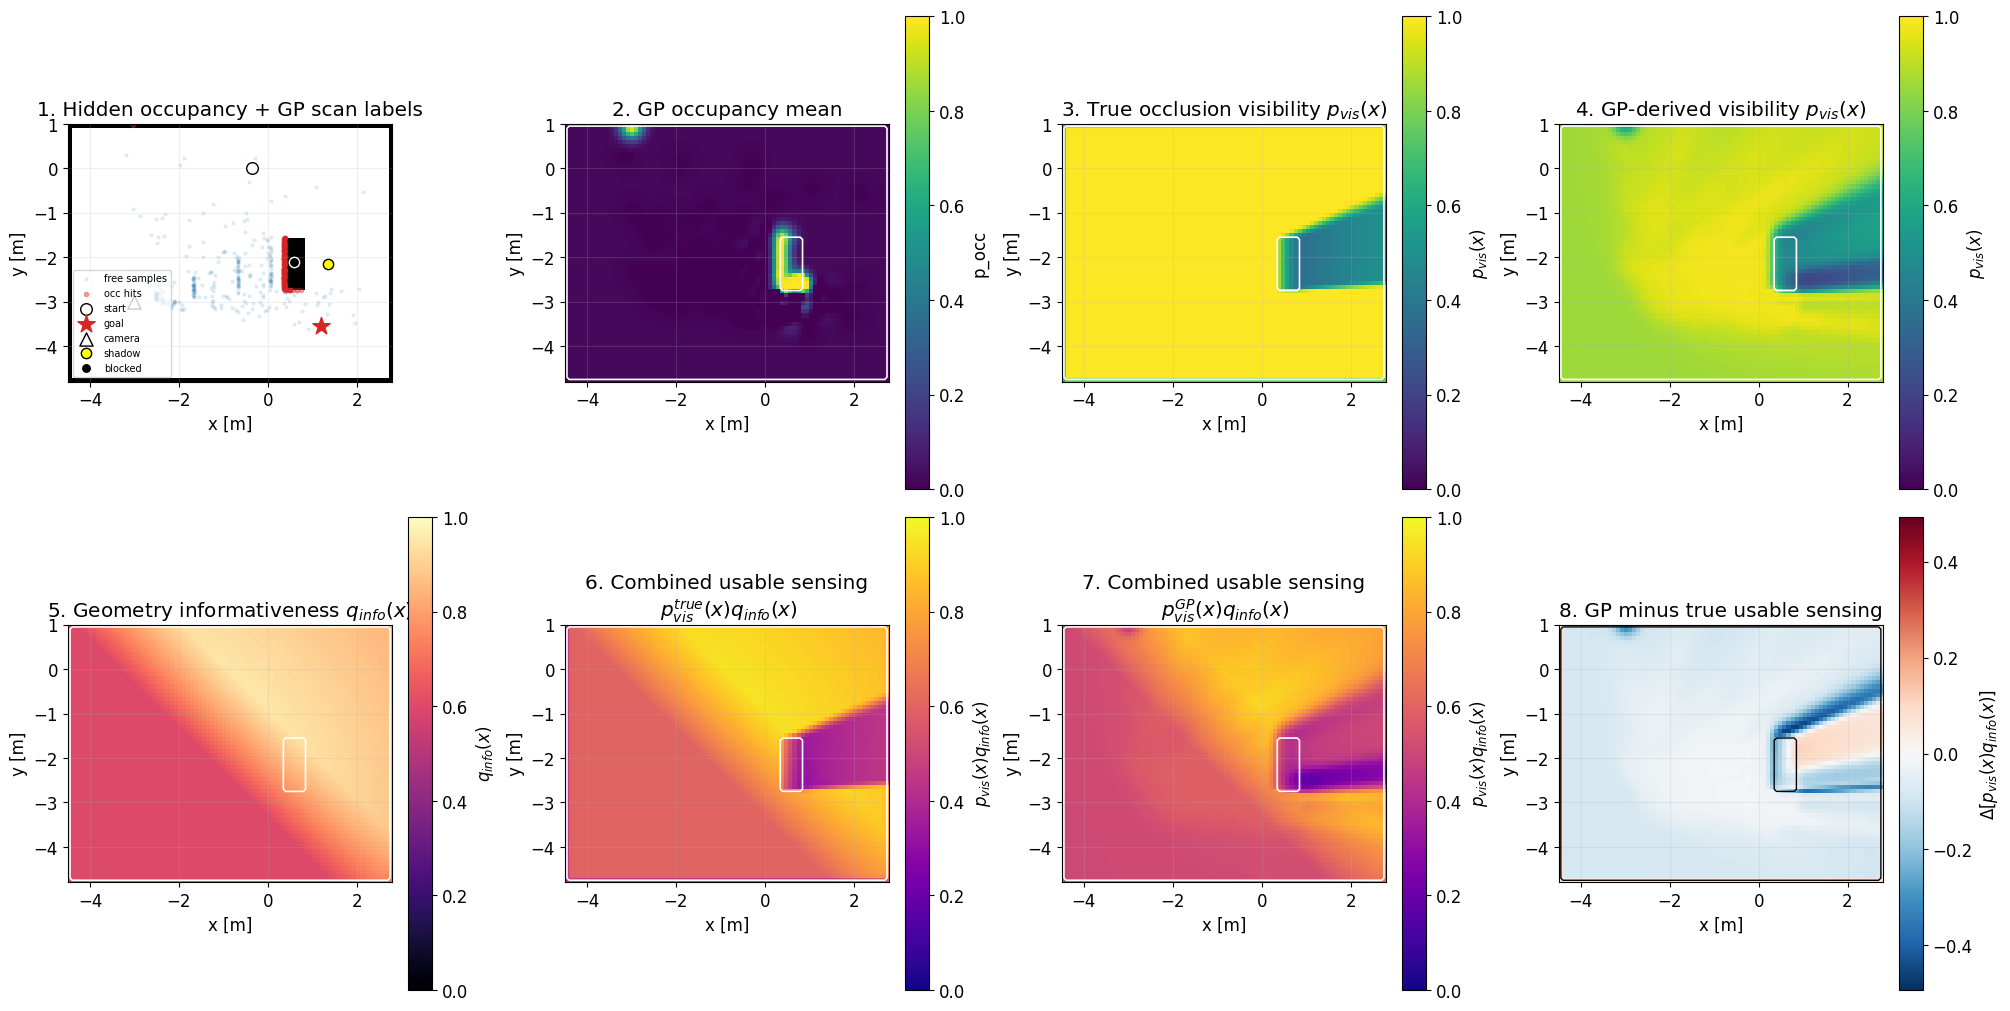

In [148]:
# Field overview:
# occupancy -> occlusion visibility -> informativeness -> combined usable sensing
#
# Note:
# combined_usable(x) = p_vis(x) * q_info(x) is only a visualization proxy.
# The planner itself uses:
#   if visible: R_info(x)
#   if not visible: R_miss
# so this scalar is for interpretation, not the exact runtime model.

vis_extent = [xs.min(), xs.max(), ys.min(), ys.max()]

combined_true_map = P_vis_true_map * Q_info_map
combined_gp_map = P_vis_gp_map * Q_info_map

p_vis_err = P_vis_gp_map - P_vis_true_map
combined_err = combined_gp_map - combined_true_map

fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)

# 1. Hidden occupancy map
axes[0, 0].imshow(
    true_grid.occupancy,
    extent=true_grid.extent,
    origin="lower",
    cmap="Greys",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
)
axes[0, 0].scatter(free_points[:, 0], free_points[:, 1], s=4, color="tab:blue", alpha=0.10, label="free samples")
axes[0, 0].scatter(occ_points[:, 0], occ_points[:, 1], s=9, color="tab:red", alpha=0.40, label="occ hits")
axes[0, 0].scatter(start_state[0], start_state[1], s=70, color="white", edgecolor="black", zorder=5, label="start")
axes[0, 0].scatter(goal_state[0], goal_state[1], marker="*", s=170, color="tab:red", zorder=5, label="goal")
axes[0, 0].scatter(camera_xy[0], camera_xy[1], marker="^", s=90, color="white", edgecolor="black", zorder=5, label="camera")
axes[0, 0].scatter(shadow_state[0], shadow_state[1], s=55, color="yellow", edgecolor="black", zorder=5, label="shadow")
axes[0, 0].scatter(blocked_state[0], blocked_state[1], s=55, color="black", edgecolor="white", zorder=5, label="blocked")
axes[0, 0].set_title("1. Hidden occupancy + GP scan labels")
axes[0, 0].legend(loc="lower left", fontsize=7)

# 2. GP occupancy mean
im = axes[0, 1].imshow(
    P_occ_gp,
    extent=vis_extent,
    origin="lower",
    cmap="viridis",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
)
axes[0, 1].contour(
    true_grid.xs,
    true_grid.ys,
    true_grid.occupancy,
    levels=[0.5],
    colors="white",
    linewidths=1.2,
)
axes[0, 1].set_title("2. GP occupancy mean")
plt.colorbar(im, ax=axes[0, 1], label="p_occ")

# 3. True occlusion visibility
im = axes[0, 2].imshow(
    P_vis_true_map,
    extent=vis_extent,
    origin="lower",
    cmap="viridis",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
)
axes[0, 2].contour(
    true_grid.xs,
    true_grid.ys,
    true_grid.occupancy,
    levels=[0.5],
    colors="white",
    linewidths=1.2,
)
axes[0, 2].set_title("3. True occlusion visibility $p_{vis}(x)$")
plt.colorbar(im, ax=axes[0, 2], label="$p_{vis}(x)$")

# 4. GP-derived occlusion visibility
im = axes[0, 3].imshow(
    P_vis_gp_map,
    extent=vis_extent,
    origin="lower",
    cmap="viridis",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
)
axes[0, 3].contour(
    true_grid.xs,
    true_grid.ys,
    true_grid.occupancy,
    levels=[0.5],
    colors="white",
    linewidths=1.2,
)
axes[0, 3].set_title("4. GP-derived visibility $p_{vis}(x)$")
plt.colorbar(im, ax=axes[0, 3], label="$p_{vis}(x)$")

# 5. Geometry informativeness
im = axes[1, 0].imshow(
    Q_info_map,
    extent=vis_extent,
    origin="lower",
    cmap="magma",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
)
axes[1, 0].contour(
    true_grid.xs,
    true_grid.ys,
    true_grid.occupancy,
    levels=[0.5],
    colors="white",
    linewidths=1.2,
)
axes[1, 0].set_title("5. Geometry informativeness $q_{info}(x)$")
plt.colorbar(im, ax=axes[1, 0], label="$q_{info}(x)$")

# 6. Combined usable sensing under true occlusion
im = axes[1, 1].imshow(
    combined_true_map,
    extent=vis_extent,
    origin="lower",
    cmap="plasma",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
)
axes[1, 1].contour(
    true_grid.xs,
    true_grid.ys,
    true_grid.occupancy,
    levels=[0.5],
    colors="white",
    linewidths=1.2,
)
axes[1, 1].set_title("6. Combined usable sensing\n$\\,p_{vis}^{true}(x) q_{info}(x)$")
plt.colorbar(im, ax=axes[1, 1], label="$p_{vis}(x) q_{info}(x)$")

# 7. Combined usable sensing under GP occlusion
im = axes[1, 2].imshow(
    combined_gp_map,
    extent=vis_extent,
    origin="lower",
    cmap="plasma",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
)
axes[1, 2].contour(
    true_grid.xs,
    true_grid.ys,
    true_grid.occupancy,
    levels=[0.5],
    colors="white",
    linewidths=1.2,
)
axes[1, 2].set_title("7. Combined usable sensing\n$\\,p_{vis}^{GP}(x) q_{info}(x)$")
plt.colorbar(im, ax=axes[1, 2], label="$p_{vis}(x) q_{info}(x)$")

# 8. GP - true difference
vmax_err = max(float(np.max(np.abs(p_vis_err))), float(np.max(np.abs(combined_err))), 1e-3)
im = axes[1, 3].imshow(
    combined_err,
    extent=vis_extent,
    origin="lower",
    cmap="RdBu_r",
    aspect="equal",
    vmin=-vmax_err,
    vmax=vmax_err,
)
axes[1, 3].contour(
    true_grid.xs,
    true_grid.ys,
    true_grid.occupancy,
    levels=[0.5],
    colors="black",
    linewidths=1.0,
)
axes[1, 3].set_title("8. GP minus true usable sensing")
plt.colorbar(im, ax=axes[1, 3], label="$\\Delta[p_{vis}(x) q_{info}(x)]$")

for ax in axes.ravel():
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

plt.show()


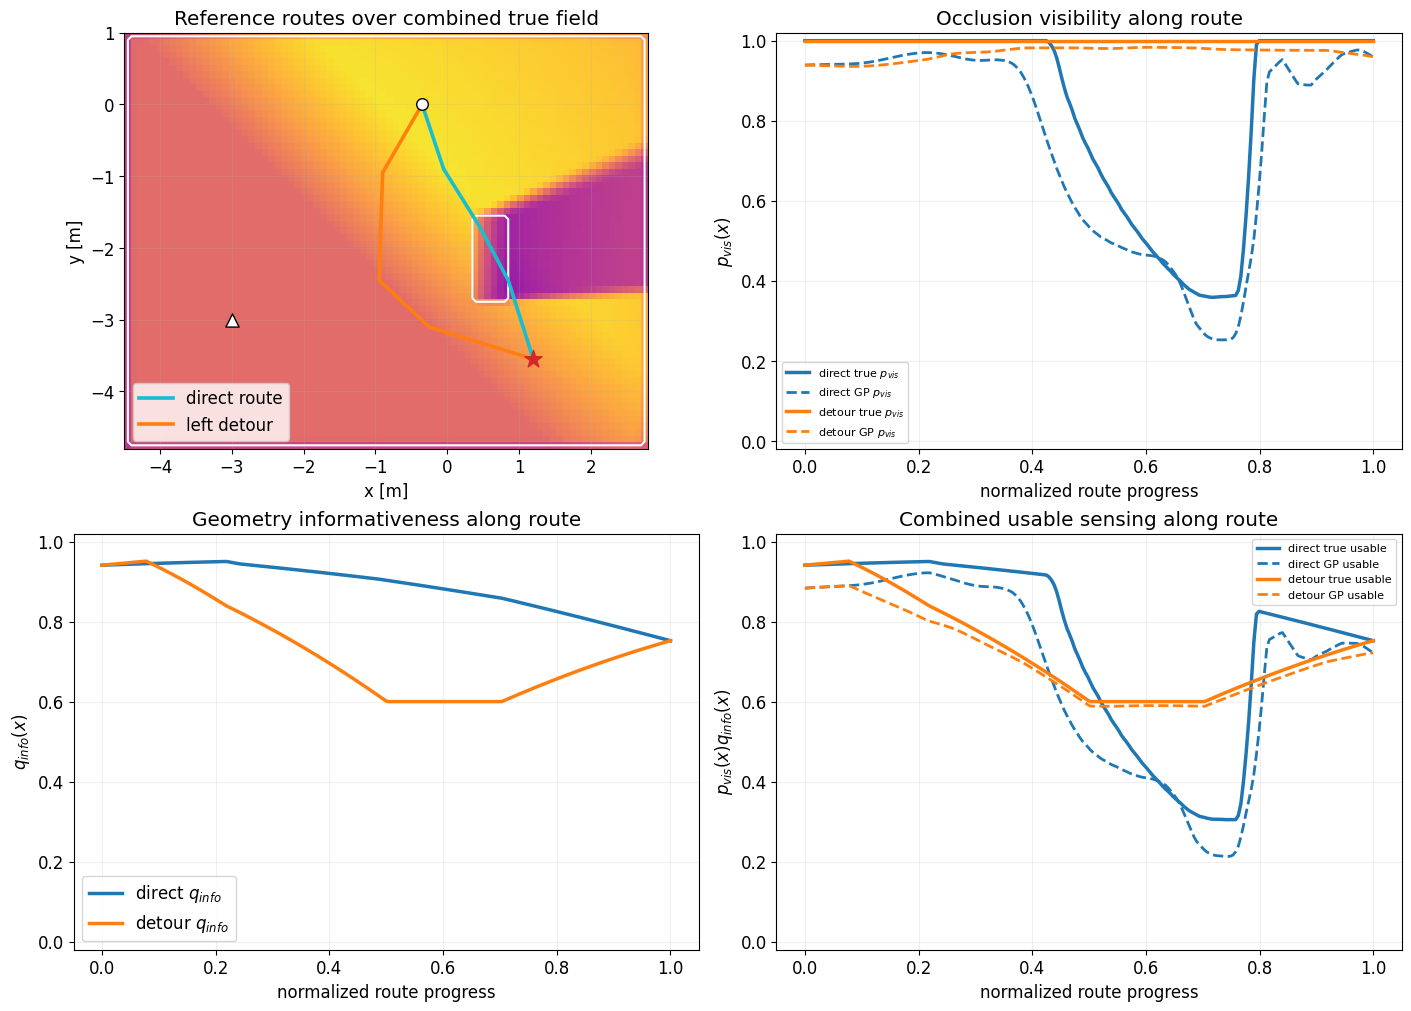

In [149]:
# Route-progression diagnostic
# This cell is only for interpretation:
# it compares how occlusion visibility, informativeness, and their product
# evolve along two hand-designed reference routes.

def sample_polyline(polyline_xy, n_points=220):
    polyline_xy = np.asarray(polyline_xy, dtype=float)
    segs = np.diff(polyline_xy, axis=0)
    seg_lens = np.linalg.norm(segs, axis=1)
    cum = np.concatenate([[0.0], np.cumsum(seg_lens)])
    total = cum[-1]
    s_query = np.linspace(0.0, total, int(n_points))

    pts = []
    idx = 0
    for s in s_query:
        while idx < len(seg_lens) - 1 and s > cum[idx + 1]:
            idx += 1
        ds = max(seg_lens[idx], 1e-9)
        alpha = (s - cum[idx]) / ds
        p = (1.0 - alpha) * polyline_xy[idx] + alpha * polyline_xy[idx + 1]
        pts.append(p)

    pts = np.asarray(pts, dtype=float)
    return s_query / max(total, 1e-9), pts


# Reference route 1:
# relatively direct path that passes closer to the occlusion wedge
direct_route = np.array([
    start_state[:2],
    [-0.05, -0.90],
    [0.45, -1.70],
    [0.85, -2.45],
    goal_state[:2],
], dtype=float)

# Reference route 2:
# visible-left detour that stays farther from the obstacle shadow
left_detour_route = np.array([
    start_state[:2],
    [-0.90, -0.95],
    [-0.95, -2.45],
    [-0.25, -3.10],
    goal_state[:2],
], dtype=float)

s_direct, pts_direct = sample_polyline(direct_route, n_points=220)
s_left, pts_left = sample_polyline(left_detour_route, n_points=220)

states_direct = np.column_stack([pts_direct, np.full(len(pts_direct), start_state[2])])
states_left = np.column_stack([pts_left, np.full(len(pts_left), start_state[2])])

pvis_true_direct = np.asarray([p_vis_true_occ(s) for s in states_direct], dtype=float)
pvis_gp_direct = np.asarray([p_vis_gp_occ(s) for s in states_direct], dtype=float)
qinfo_direct = np.asarray([q_info_geom(s) for s in states_direct], dtype=float)
usable_true_direct = pvis_true_direct * qinfo_direct
usable_gp_direct = pvis_gp_direct * qinfo_direct

pvis_true_left = np.asarray([p_vis_true_occ(s) for s in states_left], dtype=float)
pvis_gp_left = np.asarray([p_vis_gp_occ(s) for s in states_left], dtype=float)
qinfo_left = np.asarray([q_info_geom(s) for s in states_left], dtype=float)
usable_true_left = pvis_true_left * qinfo_left
usable_gp_left = pvis_gp_left * qinfo_left

combined_true_map = P_vis_true_map * Q_info_map
vis_extent = [xs.min(), xs.max(), ys.min(), ys.max()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# Map view with the two routes drawn on top
axes[0, 0].imshow(
    combined_true_map,
    extent=vis_extent,
    origin="lower",
    cmap="plasma",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
    alpha=0.95,
)
axes[0, 0].contour(
    true_grid.xs,
    true_grid.ys,
    true_grid.occupancy,
    levels=[0.5],
    colors="white",
    linewidths=1.5,
)
axes[0, 0].plot(
    direct_route[:, 0],
    direct_route[:, 1],
    color="tab:cyan",
    linewidth=2.6,
    label="direct route",
)
axes[0, 0].plot(
    left_detour_route[:, 0],
    left_detour_route[:, 1],
    color="tab:orange",
    linewidth=2.6,
    label="left detour",
)
axes[0, 0].scatter(
    start_state[0], start_state[1],
    s=70, color="white", edgecolor="black", zorder=5,
)
axes[0, 0].scatter(
    goal_state[0], goal_state[1],
    marker="*", s=170, color="tab:red", zorder=5,
)
axes[0, 0].scatter(
    camera_xy[0], camera_xy[1],
    marker="^", s=90, color="white", edgecolor="black", zorder=5,
)
axes[0, 0].set_title("Reference routes over combined true field")
axes[0, 0].set_xlabel("x [m]")
axes[0, 0].set_ylabel("y [m]")
axes[0, 0].legend(loc="lower left")

# Occlusion visibility along the routes
axes[0, 1].plot(
    s_direct, pvis_true_direct,
    color="tab:blue", linewidth=2.5, label="direct true $p_{vis}$",
)
axes[0, 1].plot(
    s_direct, pvis_gp_direct,
    color="tab:blue", linestyle="--", linewidth=2.0, label="direct GP $p_{vis}$",
)
axes[0, 1].plot(
    s_left, pvis_true_left,
    color="tab:orange", linewidth=2.5, label="detour true $p_{vis}$",
)
axes[0, 1].plot(
    s_left, pvis_gp_left,
    color="tab:orange", linestyle="--", linewidth=2.0, label="detour GP $p_{vis}$",
)
axes[0, 1].set_title("Occlusion visibility along route")
axes[0, 1].set_xlabel("normalized route progress")
axes[0, 1].set_ylabel("$p_{vis}(x)$")
axes[0, 1].set_ylim(-0.02, 1.02)
axes[0, 1].legend(fontsize=8)

# Informativeness along the routes
axes[1, 0].plot(
    s_direct, qinfo_direct,
    color="tab:blue", linewidth=2.5, label="direct $q_{info}$",
)
axes[1, 0].plot(
    s_left, qinfo_left,
    color="tab:orange", linewidth=2.5, label="detour $q_{info}$",
)
axes[1, 0].set_title("Geometry informativeness along route")
axes[1, 0].set_xlabel("normalized route progress")
axes[1, 0].set_ylabel("$q_{info}(x)$")
axes[1, 0].set_ylim(-0.02, 1.02)
axes[1, 0].legend()

# Combined usable sensing along the routes
axes[1, 1].plot(
    s_direct, usable_true_direct,
    color="tab:blue", linewidth=2.5, label="direct true usable",
)
axes[1, 1].plot(
    s_direct, usable_gp_direct,
    color="tab:blue", linestyle="--", linewidth=2.0, label="direct GP usable",
)
axes[1, 1].plot(
    s_left, usable_true_left,
    color="tab:orange", linewidth=2.5, label="detour true usable",
)
axes[1, 1].plot(
    s_left, usable_gp_left,
    color="tab:orange", linestyle="--", linewidth=2.0, label="detour GP usable",
)
axes[1, 1].set_title("Combined usable sensing along route")
axes[1, 1].set_xlabel("normalized route progress")
axes[1, 1].set_ylabel("$p_{vis}(x) q_{info}(x)$")
axes[1, 1].set_ylim(-0.02, 1.02)
axes[1, 1].legend(fontsize=8)

plt.show()


In [150]:
results = {
    "constant": run_efe_experiment(
        "constant",
        p_vis_py=lambda s: 1.0,
        q_info_py=lambda s: 1.0,
        p_vis_jax=p_vis_constant_jax,
        q_info_jax=q_info_constant_jax,
        approx=approx,
    ),
    "occ-only true": run_efe_experiment(
        "occ-only true",
        p_vis_py=p_vis_true_occ,
        q_info_py=lambda s: 1.0,
        p_vis_jax=p_vis_true_occ_jax,
        q_info_jax=q_info_constant_jax,
        approx=approx,
    ),
    "occ-only GP": run_efe_experiment(
        "occ-only GP",
        p_vis_py=p_vis_gp_occ,
        q_info_py=lambda s: 1.0,
        p_vis_jax=p_vis_gp_occ_jax,
        q_info_jax=q_info_constant_jax,
        approx=approx,
    ),
    "info-only": run_efe_experiment(
        "info-only",
        p_vis_py=lambda s: 1.0,
        q_info_py=q_info_geom,
        p_vis_jax=p_vis_constant_jax,
        q_info_jax=q_info_geom_jax,
        approx=approx,
    ),
    "combined true+info": run_efe_experiment(
        "combined true+info",
        p_vis_py=p_vis_true_occ,
        q_info_py=q_info_geom,
        p_vis_jax=p_vis_true_occ_jax,
        q_info_jax=q_info_geom_jax,
        approx=approx,
    ),
    "combined GP+info": run_efe_experiment(
        "combined GP+info",
        p_vis_py=p_vis_gp_occ,
        q_info_py=q_info_geom,
        p_vis_jax=p_vis_gp_occ_jax,
        q_info_jax=q_info_geom_jax,
        approx=approx,
    ),
}

required = {
    "true_states",
    "means",
    "covs",
    "planned_paths",
    "p_vis_exec_runtime",
    "p_vis_plan_runtime",
    "q_info_exec_runtime",
    "q_info_plan_runtime",
    "detections",
    "risk_runtime",
    "ambiguity_runtime",
    "optimizer_values",
}
for label, res in results.items():
    missing = required.difference(res.keys())
    assert not missing, f"{label} missing keys: {sorted(missing)}"


combined GP+info: 100%|██████████| 80/80 [00:27<00:00,  2.94it/s]


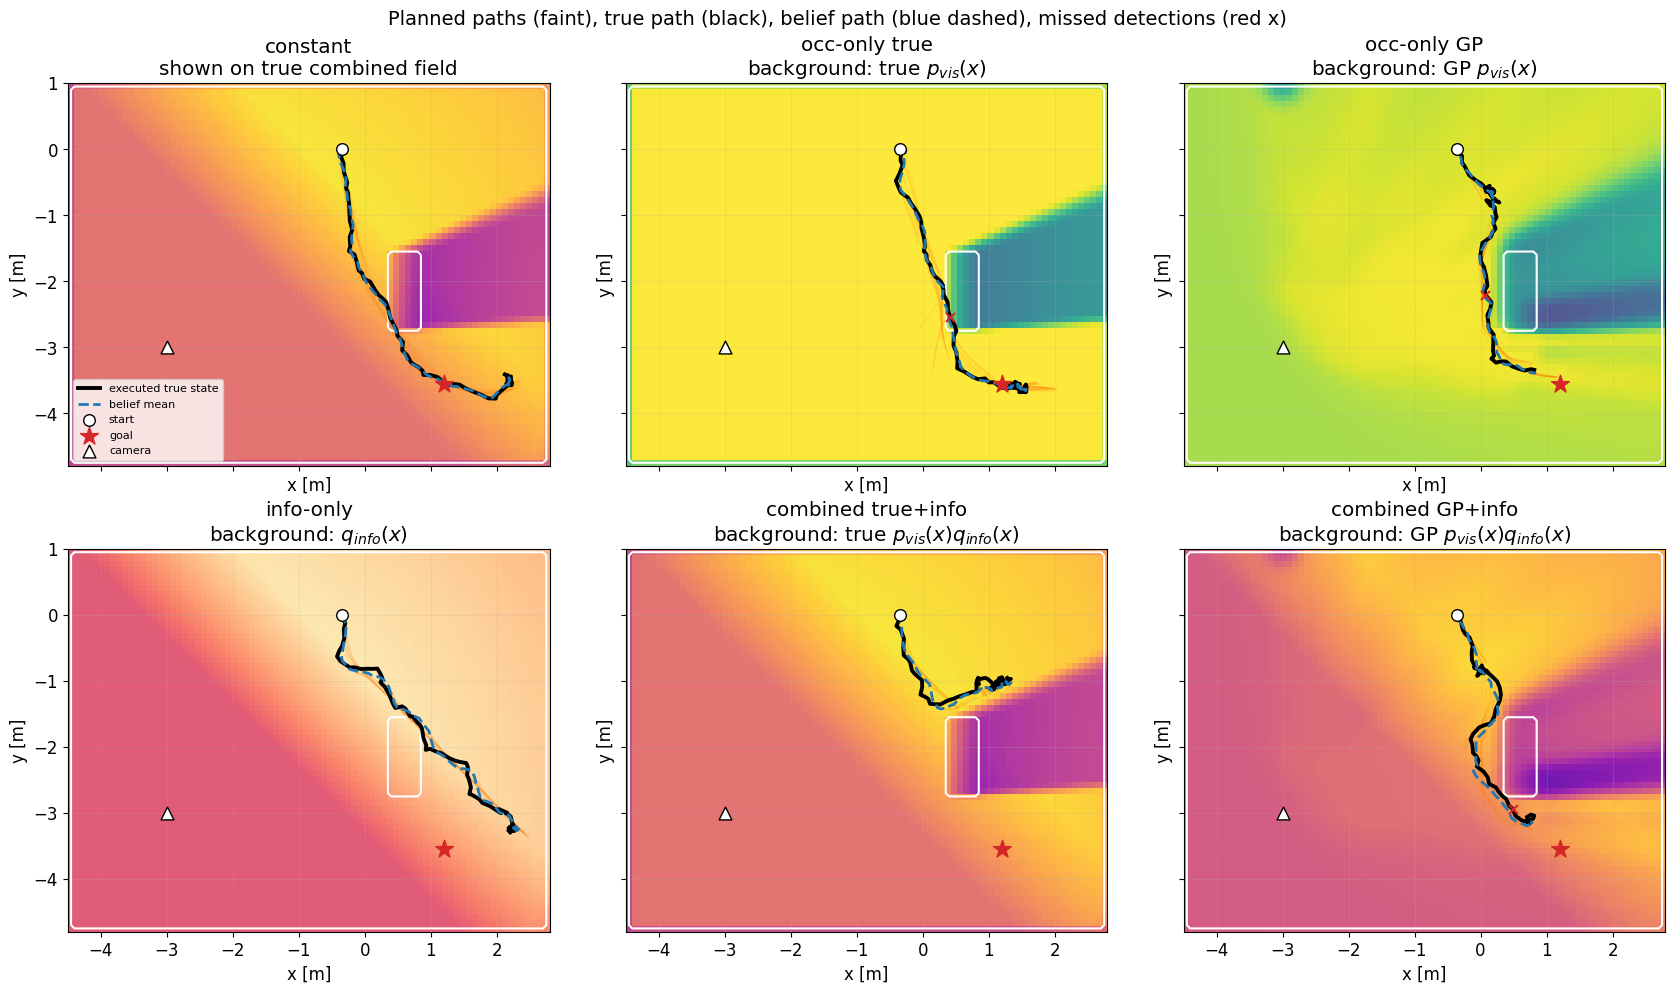

In [151]:
# Path plots for the full comparison set:
# constant, occ-only true, occ-only GP, info-only, combined true+info, combined GP+info

combined_true_map = P_vis_true_map * Q_info_map
combined_gp_map = P_vis_gp_map * Q_info_map
vis_extent = [xs.min(), xs.max(), ys.min(), ys.max()]

background_specs = {
    "constant": {
        "field": combined_true_map,
        "cmap": "plasma",
        "title_suffix": "shown on true combined field",
    },
    "occ-only true": {
        "field": P_vis_true_map,
        "cmap": "viridis",
        "title_suffix": "background: true $p_{vis}(x)$",
    },
    "occ-only GP": {
        "field": P_vis_gp_map,
        "cmap": "viridis",
        "title_suffix": "background: GP $p_{vis}(x)$",
    },
    "info-only": {
        "field": Q_info_map,
        "cmap": "magma",
        "title_suffix": "background: $q_{info}(x)$",
    },
    "combined true+info": {
        "field": combined_true_map,
        "cmap": "plasma",
        "title_suffix": "background: true $p_{vis}(x)q_{info}(x)$",
    },
    "combined GP+info": {
        "field": combined_gp_map,
        "cmap": "plasma",
        "title_suffix": "background: GP $p_{vis}(x)q_{info}(x)$",
    },
}

items = list(results.items())
ncols = 3
nrows = int(np.ceil(len(items) / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(17, 9.8), constrained_layout=True, sharex=True, sharey=True
)
axes = np.atleast_1d(axes).ravel()

for ax, (label, res) in zip(axes, items):
    spec = background_specs[label]
    field = spec["field"]
    cmap = spec["cmap"]

    ax.imshow(
        field,
        extent=vis_extent,
        origin="lower",
        cmap=cmap,
        aspect="equal",
        alpha=0.90,
        vmin=0.0,
        vmax=1.0,
    )

    # True obstacle outline
    ax.contour(
        true_grid.xs,
        true_grid.ys,
        true_grid.occupancy,
        levels=[0.5],
        colors="white",
        linewidths=1.5,
    )

    # Faint replanned trajectories
    for path in res["planned_paths"]:
        ax.plot(
            path[:, 0],
            path[:, 1],
            color="tab:orange",
            alpha=0.14,
            linewidth=1.0,
        )

    # Executed true path
    ax.plot(
        res["true_states"][:, 0],
        res["true_states"][:, 1],
        color="black",
        linewidth=2.8,
        label="executed true state",
        zorder=4,
    )

    # Belief path
    ax.plot(
        res["means"][:, 0],
        res["means"][:, 1],
        color="tab:blue",
        linewidth=2.0,
        linestyle="--",
        label="belief mean",
        zorder=4,
    )

    # Missed detections along the true path
    miss_idx = np.where(~res["detections"])[0]
    if miss_idx.size:
        ax.scatter(
            res["true_states"][miss_idx, 0],
            res["true_states"][miss_idx, 1],
            marker="x",
            s=42,
            color="tab:red",
            linewidths=1.5,
            label="missed detection",
            zorder=5,
        )

    ax.scatter(
        start_state[0], start_state[1],
        s=70, color="white", edgecolor="black",
        label="start", zorder=6,
    )
    ax.scatter(
        goal_state[0], goal_state[1],
        marker="*", s=180, color="tab:red",
        label="goal", zorder=6,
    )
    ax.scatter(
        camera_xy[0], camera_xy[1],
        marker="^", s=85, color="white", edgecolor="black",
        label="camera", zorder=6,
    )

    ax.set_title(f"{label}\n{spec['title_suffix']}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

# Hide any unused axes
for ax in axes[len(items):]:
    ax.axis("off")

axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle(
    "Planned paths (faint), true path (black), belief path (blue dashed), missed detections (red x)",
    fontsize=14,
)
plt.show()


KeyError: 'q_exec_runtime'

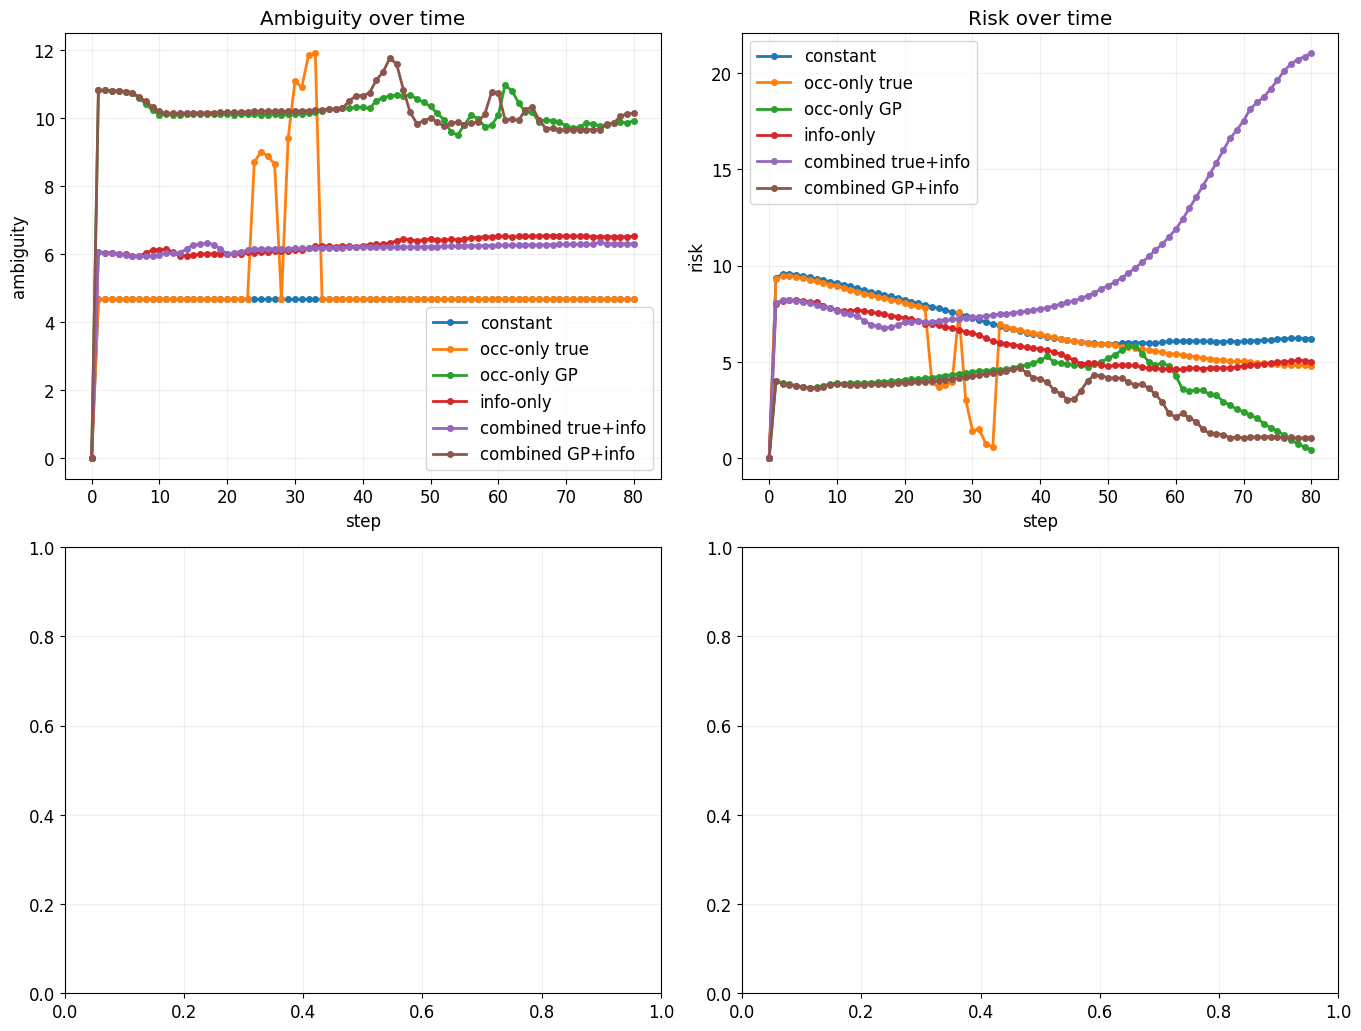

In [152]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.2), constrained_layout=True)

for label, res in results.items():
    axes[0, 0].plot(
        res["ambiguity_runtime"],
        marker="o",
        linewidth=2,
        markersize=4,
        label=label,
    )
axes[0, 0].set_title("Ambiguity over time")
axes[0, 0].set_xlabel("step")
axes[0, 0].set_ylabel("ambiguity")
axes[0, 0].legend()

for label, res in results.items():
    axes[0, 1].plot(
        res["risk_runtime"],
        marker="o",
        linewidth=2,
        markersize=4,
        label=label,
    )
axes[0, 1].set_title("Risk over time")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylabel("risk")
axes[0, 1].legend()

for label, res in results.items():
    steps = np.arange(len(res["q_exec_runtime"]))

    axes[1, 0].plot(
        steps,
        res["q_exec_runtime"],
        marker="o",
        linewidth=2,
        markersize=4,
        label=f"{label} exec q(x)",
    )
    axes[1, 0].plot(
        steps,
        res["q_plan_runtime"],
        linestyle="--",
        linewidth=1.8,
        alpha=0.9,
        label=f"{label} plan q(x)",
    )

    miss_idx = np.where(~res["detections"])[0]
    if miss_idx.size:
        axes[1, 0].scatter(
            miss_idx,
            res["q_exec_runtime"][miss_idx],
            marker="x",
            s=55,
            linewidths=1.6,
            label=f"{label} missed detect",
        )

axes[1, 0].set_title("Executed vs planner-assumed visibility")
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("q(x)")
axes[1, 0].set_ylim(-0.02, 1.02)
axes[1, 0].legend(fontsize=8)

for label, res in results.items():
    axes[1, 1].plot(
        covariance_trace_series(res["covs"]),
        marker="o",
        linewidth=2,
        markersize=4,
        label=label,
    )
axes[1, 1].set_title("Belief covariance trace")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("trace(P)")
axes[1, 1].legend()

plt.show()


In [ ]:
summary_rows = []
for label, res in results.items():
    summary_rows.append({
        "model": label,
        "final_true_goal_dist": float(np.linalg.norm(res["true_states"][-1, :2] - goal_state[:2])),
        "final_belief_goal_dist": float(np.linalg.norm(res["means"][-1, :2] - goal_state[:2])),
        "cum_risk": float(np.sum(res["risk_runtime"])),
        "cum_ambiguity": float(np.sum(res["ambiguity_runtime"])),
        "mean_q_exec": float(np.mean(res["q_exec_runtime"][1:])),
        "min_q_exec": float(np.min(res["q_exec_runtime"][1:])),
        "mean_q_plan": float(np.mean(res["q_plan_runtime"][1:])),
        "min_q_plan": float(np.min(res["q_plan_runtime"][1:])),
        "detection_rate": float(np.mean(res["detections"][1:])),
        "missed_detection_frac": float(np.mean(~res["detections"][1:])),
        "mean_abs_q_mismatch": float(np.mean(np.abs(res["q_plan_runtime"][1:] - res["q_exec_runtime"][1:]))),
        "final_trace": float(covariance_trace_series(res["covs"])[-1]),
        "final_logdet": float(covariance_logdet_series(res["covs"])[-1]),
        "mean_optimizer_value": float(np.mean(res["optimizer_values"][1:])),
    })

summary_df = pd.DataFrame(summary_rows)
print("Experiment summary:")
display(summary_df)


Experiment summary:


,model,final_true_goal_dist,final_belief_goal_dist,cum_risk,cum_ambiguity,mean_q_exec,min_q_exec,mean_q_plan,min_q_plan,detection_rate,missed_detection_frac,mean_abs_q_mismatch,final_trace,final_logdet,mean_optimizer_value
0,constant R,0.422706,0.360098,661.735757,467.128886,0.895132,0.289080,1.000000,1.000000,0.84,0.16,0.104868,0.029273,-22.392861,62.868749
1,true-map q(x),0.345072,0.323566,683.995844,471.868360,0.982405,0.769736,0.999794,0.993004,0.96,0.04,0.017528,0.015805,-22.766765,66.281477
2,GP-occ q(x),0.621509,0.611858,894.828892,659.966372,1.000000,1.000000,0.983774,0.880276,1.00,0.00,0.016226,0.025351,-22.314476,89.831474


In [165]:
# ET1 vs ET2 helper for the current notebook state.
# This matches the current runner exactly:
# planner-side p_vis and q_info are evaluated at the belief mean m_k.

def make_noise_pack(seed, len_trial=len_trial, dy=agent.Dy):
    local_rng = np.random.default_rng(int(seed))
    return {
        "w_exec": local_rng.multivariate_normal(np.zeros(3), Q_exec, size=len_trial),
        "u_detect": local_rng.random(len_trial),
        "meas_eps": local_rng.standard_normal((len_trial, dy)),
    }


def run_efe_experiment_fixed_noise(
    label,
    p_vis_py,
    q_info_py,
    p_vis_jax,
    q_info_jax,
    *,
    noise_pack,
    approx="ET2",
):
    valgrad = make_state_dependent_valgrad_fn(
        p_vis_jax,
        q_info_jax,
        approx=approx,
        add_ambiguity=True,
    )

    z_sim = np.zeros((3, len_trial))
    y_sim = np.full((agent.Dy, len_trial), np.nan)
    u_sim = np.zeros((2, len_trial))
    z_est_mean = np.zeros((3, len_trial))
    z_est_cov = np.zeros((3, 3, len_trial))

    risk_runtime = np.zeros(len_trial)
    ambiguity_runtime = np.zeros(len_trial)
    p_vis_exec_runtime = np.ones(len_trial)
    p_vis_plan_runtime = np.ones(len_trial)
    q_info_exec_runtime = np.ones(len_trial)
    q_info_plan_runtime = np.ones(len_trial)
    detections = np.ones(len_trial, dtype=bool)
    F_runtime = np.full(len_trial, np.nan)
    optimizer_values = np.zeros(len_trial)

    z_sim[:, 0] = start_state
    y_sim[:, 0] = g(start_state)
    z_est_mean[:, 0] = mean0
    z_est_cov[:, :, 0] = cov0

    m_kmin1 = mean0.copy()
    S_kmin1 = cov0.copy()
    policy = np.zeros((2, horizon))
    planned_paths = []

    for k in tqdm(range(1, len_trial), desc=label):
        z_sim[:, k] = unicycle_step(z_sim[:, k - 1], u_sim[:, k - 1], dt)
        z_sim[:, k] = z_sim[:, k] + noise_pack["w_exec"][k]
        z_sim[2, k] = wrap_angle(z_sim[2, k])

        p_vis_exec = float(np.clip(p_vis_py(z_sim[:, k]), 0.0, 1.0))
        q_info_exec = float(np.clip(q_info_py(z_sim[:, k]), 0.0, 1.0))
        p_detect = p_vis_exec ** detection_power
        detected = bool(noise_pack["u_detect"][k] < p_detect)

        m_pred, S_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k - 1])

        if detected:
            R_exec = visible_cov_np(q_info_exec)
            y_mean = np.asarray(g(z_sim[:, k]), dtype=float)
            L_exec = np.linalg.cholesky(R_exec)
            y_sim[:, k] = y_mean + L_exec @ noise_pack["meas_eps"][k]

            m_k, S_k = correct_with_R(y_sim[:, k], m_pred, S_pred, R_exec, approx=approx)
            F_runtime[k] = evidence_with_R(y_sim[:, k], m_pred, S_pred, R_exec, approx=approx)
        else:
            m_k, S_k = m_pred, S_pred

        z_est_mean[:, k] = m_k
        z_est_cov[:, :, k] = S_k

        p_vis_plan = float(np.clip(p_vis_py(m_k), 0.0, 1.0))
        q_info_plan = float(np.clip(q_info_py(m_k), 0.0, 1.0))
        R_plan_np = p_vis_plan * visible_cov_np(q_info_plan) + (1.0 - p_vis_plan) * R_miss
        mu_y, Sigma_y, Gamma = observation_moments_np(m_k, S_k, R_plan_np, approx=approx)

        p_vis_exec_runtime[k] = p_vis_exec
        p_vis_plan_runtime[k] = p_vis_plan
        q_info_exec_runtime[k] = q_info_exec
        q_info_plan_runtime[k] = q_info_plan
        detections[k] = detected

        goal_cov_k = goal_cov_for_step(k)
        risk_runtime[k] = float(risk(mu_y, Sigma_y, (goal_obs, goal_cov_k)))
        ambiguity_runtime[k] = float(ambiguity(Sigma_y, Gamma, S_k))

        k0 = jnp.asarray(float(k), dtype=jnp.float64)

        def f(u):
            val, _ = valgrad(jnp.asarray(u), jnp.asarray(m_k), jnp.asarray(S_k), k0)
            return float(val)

        def grad_u(u):
            _, grad = valgrad(jnp.asarray(u), jnp.asarray(m_k), jnp.asarray(S_k), k0)
            return np.asarray(grad, dtype=float)

        x0 = np.zeros(2 * horizon) if k == 1 else np.concatenate(
            [policy[:, 1:].T.reshape(-1), policy[:, -1]]
        )

        result = minimize(
            f,
            x0,
            jac=grad_u,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 120, "maxfun": 1200, "ftol": 1e-6},
        )

        optimizer_values[k] = float(result.fun)
        policy = np.asarray(result.x, dtype=float).reshape((horizon, 2)).T
        u_sim[:, k] = policy[:, 0]

        planned_states, _ = planned_trajectory_unicycle(agent, policy, (m_k, S_k), approx=approx)
        planned_paths.append(planned_states[0].T.copy())

        m_kmin1 = m_k
        S_kmin1 = S_k

    return {
        "label": label,
        "approx": approx,
        "true_states": z_sim.T,
        "means": z_est_mean.T,
        "covs": np.moveaxis(z_est_cov, 2, 0),
        "measurements": y_sim.T,
        "chosen_controls": u_sim.T,
        "planned_paths": planned_paths,
        "p_vis_exec_runtime": p_vis_exec_runtime,
        "p_vis_plan_runtime": p_vis_plan_runtime,
        "q_info_exec_runtime": q_info_exec_runtime,
        "q_info_plan_runtime": q_info_plan_runtime,
        "detections": detections,
        "risk_runtime": risk_runtime,
        "ambiguity_runtime": ambiguity_runtime,
        "log_evidence_runtime": F_runtime,
        "optimizer_values": optimizer_values,
    }


In [166]:
# ET1 vs ET2 for:
# 1. GP p_vis only
# 2. GP p_vis + q_info
#
# Each model uses shared noise between ET1 and ET2.

q_info_const_py = lambda s: 1.0

et_compare_specs = {
    "GP p_vis": {
        "p_vis_py": p_vis_gp_occ,
        "q_info_py": q_info_const_py,
        "p_vis_jax": p_vis_gp_occ_jax,
        "q_info_jax": q_info_constant_jax,
    },
    "GP p_vis + q_info": {
        "p_vis_py": p_vis_gp_occ,
        "q_info_py": q_info_geom,
        "p_vis_jax": p_vis_gp_occ_jax,
        "q_info_jax": q_info_geom_jax,
    },
}

shared_noise = {
    model_label: make_noise_pack(20260316 + i)
    for i, model_label in enumerate(et_compare_specs.keys())
}

et_compare = {}
for model_label, spec in et_compare_specs.items():
    et_compare[model_label] = {
        "ET1": run_efe_experiment_fixed_noise(
            f"{model_label} [ET1]",
            spec["p_vis_py"],
            spec["q_info_py"],
            spec["p_vis_jax"],
            spec["q_info_jax"],
            noise_pack=shared_noise[model_label],
            approx="ET1",
        ),
        "ET2": run_efe_experiment_fixed_noise(
            f"{model_label} [ET2]",
            spec["p_vis_py"],
            spec["q_info_py"],
            spec["p_vis_jax"],
            spec["q_info_jax"],
            noise_pack=shared_noise[model_label],
            approx="ET2",
        ),
    }


GP p_vis + q_info [ET2]: 100%|██████████| 80/80 [00:33<00:00,  2.37it/s]


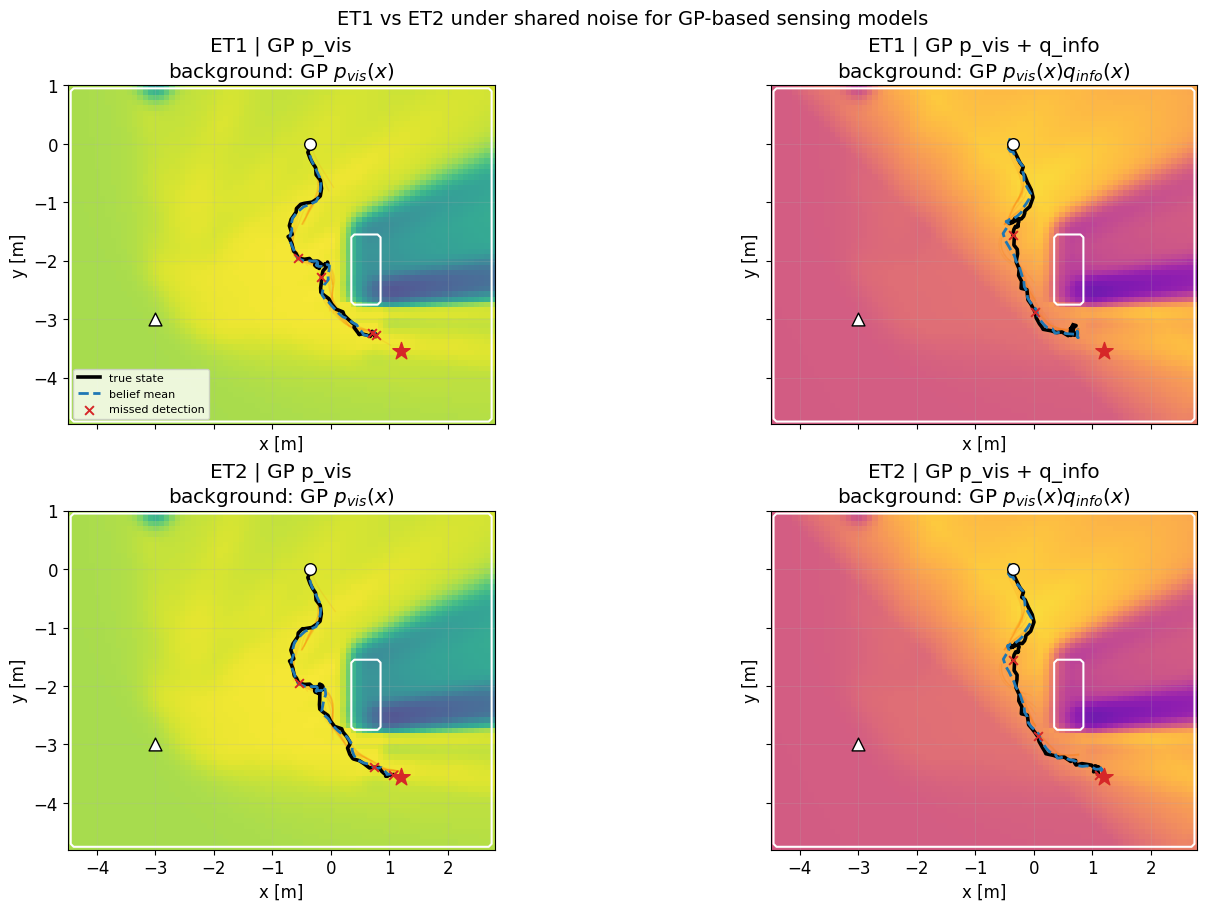

In [167]:
# Path comparison: rows ET1 / ET2, columns GP p_vis / GP p_vis + q_info

comparison_backgrounds = {
    "GP p_vis": {
        "field": P_vis_gp_map,
        "cmap": "viridis",
        "title_suffix": "background: GP $p_{vis}(x)$",
    },
    "GP p_vis + q_info": {
        "field": P_vis_gp_map * Q_info_map,
        "cmap": "plasma",
        "title_suffix": "background: GP $p_{vis}(x)q_{info}(x)$",
    },
}

vis_extent = [xs.min(), xs.max(), ys.min(), ys.max()]
model_order = list(et_compare_specs.keys())
approx_order = ["ET1", "ET2"]

fig, axes = plt.subplots(
    2, len(model_order), figsize=(14, 9), constrained_layout=True, sharex=True, sharey=True
)

for row, approx_name in enumerate(approx_order):
    for col, model_label in enumerate(model_order):
        ax = axes[row, col]
        res = et_compare[model_label][approx_name]
        spec = comparison_backgrounds[model_label]

        ax.imshow(
            spec["field"],
            extent=vis_extent,
            origin="lower",
            cmap=spec["cmap"],
            aspect="equal",
            alpha=0.90,
            vmin=0.0,
            vmax=1.0,
        )

        ax.contour(
            true_grid.xs,
            true_grid.ys,
            true_grid.occupancy,
            levels=[0.5],
            colors="white",
            linewidths=1.5,
        )

        for path in res["planned_paths"]:
            ax.plot(
                path[:, 0],
                path[:, 1],
                color="tab:orange",
                alpha=0.14,
                linewidth=1.0,
            )

        ax.plot(
            res["true_states"][:, 0],
            res["true_states"][:, 1],
            color="black",
            linewidth=2.6,
            label="true state",
            zorder=4,
        )

        ax.plot(
            res["means"][:, 0],
            res["means"][:, 1],
            color="tab:blue",
            linewidth=2.0,
            linestyle="--",
            label="belief mean",
            zorder=4,
        )

        miss_idx = np.where(~res["detections"])[0]
        if miss_idx.size:
            ax.scatter(
                res["true_states"][miss_idx, 0],
                res["true_states"][miss_idx, 1],
                marker="x",
                s=40,
                color="tab:red",
                linewidths=1.4,
                label="missed detection",
                zorder=5,
            )

        ax.scatter(start_state[0], start_state[1], s=70, color="white", edgecolor="black", zorder=6)
        ax.scatter(goal_state[0], goal_state[1], marker="*", s=170, color="tab:red", zorder=6)
        ax.scatter(camera_xy[0], camera_xy[1], marker="^", s=85, color="white", edgecolor="black", zorder=6)

        ax.set_title(f"{approx_name} | {model_label}\n{spec['title_suffix']}")
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        ax.set_aspect("equal")

axes[0, 0].legend(loc="lower left", fontsize=8)
fig.suptitle("ET1 vs ET2 under shared noise for GP-based sensing models", fontsize=14)
plt.show()


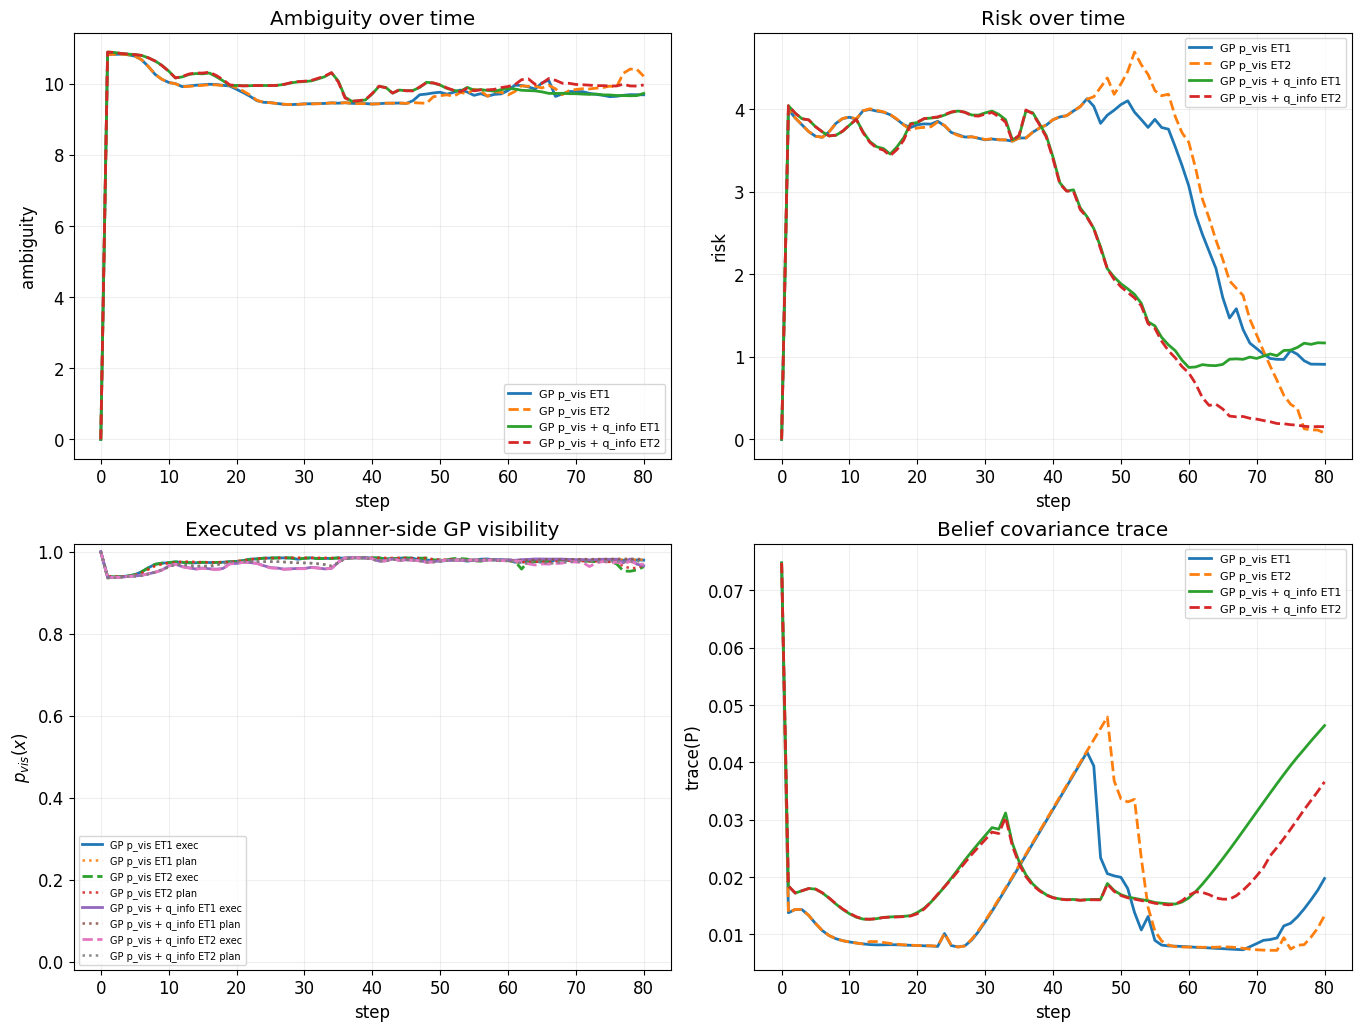

In [168]:
# Time-series comparison

fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.2), constrained_layout=True)

for model_label in model_order:
    for approx_name, style in [("ET1", "-"), ("ET2", "--")]:
        res = et_compare[model_label][approx_name]
        axes[0, 0].plot(
            res["ambiguity_runtime"],
            linestyle=style,
            linewidth=2,
            label=f"{model_label} {approx_name}",
        )
axes[0, 0].set_title("Ambiguity over time")
axes[0, 0].set_xlabel("step")
axes[0, 0].set_ylabel("ambiguity")
axes[0, 0].legend(fontsize=8)

for model_label in model_order:
    for approx_name, style in [("ET1", "-"), ("ET2", "--")]:
        res = et_compare[model_label][approx_name]
        axes[0, 1].plot(
            res["risk_runtime"],
            linestyle=style,
            linewidth=2,
            label=f"{model_label} {approx_name}",
        )
axes[0, 1].set_title("Risk over time")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylabel("risk")
axes[0, 1].legend(fontsize=8)

for model_label in model_order:
    for approx_name, style in [("ET1", "-"), ("ET2", "--")]:
        res = et_compare[model_label][approx_name]
        axes[1, 0].plot(
            res["p_vis_exec_runtime"],
            linestyle=style,
            linewidth=2,
            label=f"{model_label} {approx_name} exec",
        )
        axes[1, 0].plot(
            res["p_vis_plan_runtime"],
            linestyle=":",
            linewidth=1.8,
            alpha=0.9,
            label=f"{model_label} {approx_name} plan",
        )
axes[1, 0].set_title("Executed vs planner-side GP visibility")
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("$p_{vis}(x)$")
axes[1, 0].set_ylim(-0.02, 1.02)
axes[1, 0].legend(fontsize=7)

for model_label in model_order:
    for approx_name, style in [("ET1", "-"), ("ET2", "--")]:
        res = et_compare[model_label][approx_name]
        axes[1, 1].plot(
            covariance_trace_series(res["covs"]),
            linestyle=style,
            linewidth=2,
            label=f"{model_label} {approx_name}",
        )
axes[1, 1].set_title("Belief covariance trace")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("trace(P)")
axes[1, 1].legend(fontsize=8)

plt.show()


In [169]:
# Summary table and ET2-ET1 deltas

summary_rows = []
delta_rows = []

for model_label in model_order:
    et1 = et_compare[model_label]["ET1"]
    et2 = et_compare[model_label]["ET2"]

    for approx_name, res in [("ET1", et1), ("ET2", et2)]:
        state_err = np.linalg.norm(res["true_states"][:, :2] - res["means"][:, :2], axis=1)
        summary_rows.append({
            "model": model_label,
            "approx": approx_name,
            "final_true_goal_dist": float(np.linalg.norm(res["true_states"][-1, :2] - goal_state[:2])),
            "final_belief_goal_dist": float(np.linalg.norm(res["means"][-1, :2] - goal_state[:2])),
            "mean_state_error": float(np.mean(state_err)),
            "detection_rate": float(np.mean(res["detections"][1:])),
            "mean_p_vis_exec": float(np.mean(res["p_vis_exec_runtime"][1:])),
            "mean_p_vis_plan": float(np.mean(res["p_vis_plan_runtime"][1:])),
            "mean_q_info_exec": float(np.mean(res["q_info_exec_runtime"][1:])),
            "mean_q_info_plan": float(np.mean(res["q_info_plan_runtime"][1:])),
            "cum_risk": float(np.sum(res["risk_runtime"])),
            "cum_ambiguity": float(np.sum(res["ambiguity_runtime"])),
            "final_trace": float(covariance_trace_series(res["covs"])[-1]),
            "mean_optimizer_value": float(np.mean(res["optimizer_values"][1:])),
        })

    delta_rows.append({
        "model": model_label,
        "delta_final_true_goal_dist_ET2_minus_ET1": float(
            np.linalg.norm(et2["true_states"][-1, :2] - goal_state[:2])
            - np.linalg.norm(et1["true_states"][-1, :2] - goal_state[:2])
        ),
        "delta_mean_state_error_ET2_minus_ET1": float(
            np.mean(np.linalg.norm(et2["true_states"][:, :2] - et2["means"][:, :2], axis=1))
            - np.mean(np.linalg.norm(et1["true_states"][:, :2] - et1["means"][:, :2], axis=1))
        ),
        "delta_detection_rate_ET2_minus_ET1": float(
            np.mean(et2["detections"][1:]) - np.mean(et1["detections"][1:])
        ),
        "delta_final_trace_ET2_minus_ET1": float(
            covariance_trace_series(et2["covs"])[-1] - covariance_trace_series(et1["covs"])[-1]
        ),
        "delta_cum_risk_ET2_minus_ET1": float(
            np.sum(et2["risk_runtime"]) - np.sum(et1["risk_runtime"])
        ),
        "delta_cum_ambiguity_ET2_minus_ET1": float(
            np.sum(et2["ambiguity_runtime"]) - np.sum(et1["ambiguity_runtime"])
        ),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["model", "approx"]).reset_index(drop=True)
delta_df = pd.DataFrame(delta_rows)

print("ET1 / ET2 summary")
display(summary_df)

print("ET2 minus ET1 deltas")
display(delta_df)


ET1 / ET2 summary


,model,approx,final_true_goal_dist,final_belief_goal_dist,mean_state_error,detection_rate,mean_p_vis_exec,mean_p_vis_plan,mean_q_info_exec,mean_q_info_plan,cum_risk,cum_ambiguity,final_trace,mean_optimizer_value
0,GP p_vis,ET1,0.510471,0.525214,0.047097,0.9500,0.976761,0.976905,1.000000,1.000000,255.737476,782.758402,0.019714,96.613518
1,GP p_vis,ET2,0.143842,0.156878,0.046851,0.9625,0.975332,0.975922,1.000000,1.000000,260.371604,785.667324,0.013248,96.904346
2,GP p_vis + q_info,ET1,0.693973,0.594339,0.078793,0.9750,0.970517,0.973385,0.798943,0.798091,211.003965,798.804845,0.046413,96.455785
3,GP p_vis + q_info,ET2,0.225908,0.115710,0.082108,0.9625,0.968507,0.971641,0.804344,0.804418,195.227603,804.575351,0.036587,96.266461


ET2 minus ET1 deltas


,model,delta_final_true_goal_dist_ET2_minus_ET1,delta_mean_state_error_ET2_minus_ET1,delta_detection_rate_ET2_minus_ET1,delta_final_trace_ET2_minus_ET1,delta_cum_risk_ET2_minus_ET1,delta_cum_ambiguity_ET2_minus_ET1
0,GP p_vis,-0.366629,-0.000245,0.0125,-0.006467,4.634129,2.908921
1,GP p_vis + q_info,-0.468065,0.003315,-0.0125,-0.009826,-15.776363,5.770506
